# 1-Education Status of Voters in 2018 Parliamentary General Elections

In [2]:
import os
import pandas as pd
import re
folder_path = ("data/raw/election/voters-age-sex-education/2018")
files = os.listdir(folder_path) 
files[:3] # check first 3 file names

['Adana.xlsx', 'Adıyaman.xlsx', 'Afyonkarahisar.xlsx']

### 0.Understanding Data

Examine a sample file
Let's get header columns

In [3]:
file_name=files[0]
file_path = os.path.join(folder_path,file_name)
df_sub = pd.read_excel(file_path,skiprows=7)
df_sub.head()

,Adana,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Aladağ,NaN,Okuma yazma bilmeyen,Okuma yazma bilen fakat bir okul bitirmeyen,İlkokul,İlköğretim,Ortaokul veya dengi okul,Lise veya dengi okul,Yüksekokul veya fakülte,Yüksek lisans,Doktora,Bilinmeyen,Toplam
1,18-24,Erkek,-,6,3,197,120,525,144,-,-,-,995
2,NaN,Kadın,-,16,9,241,70,422,114,-,-,-,872
3,25-29,Erkek,1,2,-,196,1,187,174,8,-,-,569
4,NaN,Kadın,2,14,1,213,-,122,131,1,-,-,484


In [4]:
education_columns = df_sub.iloc[0,2:].tolist()
print(education_columns)

['Okuma yazma bilmeyen', 'Okuma yazma bilen fakat bir okul bitirmeyen', 'İlkokul', 'İlköğretim', 'Ortaokul veya dengi okul', 'Lise veya dengi okul', 'Yüksekokul veya fakülte', 'Yüksek lisans', 'Doktora', 'Bilinmeyen', 'Toplam']


In [5]:
edu_levels_eng =   ['illiterate', 'literate but did not complete any school', 'primary school', 'elementary school', 'secondary school or equivalent', 'high school or equivalent', 'pre-license or bachelor degree', 'master degree', 'phd', 'unknown', 'total']
edu_translate = {}
for i, level in enumerate(education_columns):
    edu_translate[level] = edu_levels_eng[i]  
age_translate = {"Erkek": "male", "Kadın": "female"}

* Heading is not important for now. Actual heading repeats at every 26th row along with the district name.
In other words; the first row includes  district name and education levels which will be actual headings.
* Next 24 rows (12x2) represent data for 12 age groups and 2 genders.
* 26th row represents total for that district
* After the first row, age groups follow. Rows with even indices in this column contain **NaN**s.
To fill NaN values we can use ffill method. 

Obtain age groups. There are 12 age groups.

In [6]:
age_groups = sorted(list({row for row in df_sub.iloc[:-2,0] if re.search(r'\d+', str(row))} )) 
print(age_groups)

['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75+']


**Step-1 Test:** Apply ffill on the first column and check again.

In [7]:
df_sub.iloc[:,0]=df_sub.iloc[:,0].ffill()
df_sub.head()

,Adana,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Aladağ,NaN,Okuma yazma bilmeyen,Okuma yazma bilen fakat bir okul bitirmeyen,İlkokul,İlköğretim,Ortaokul veya dengi okul,Lise veya dengi okul,Yüksekokul veya fakülte,Yüksek lisans,Doktora,Bilinmeyen,Toplam
1,18-24,Erkek,-,6,3,197,120,525,144,-,-,-,995
2,18-24,Kadın,-,16,9,241,70,422,114,-,-,-,872
3,25-29,Erkek,1,2,-,196,1,187,174,8,-,-,569
4,25-29,Kadın,2,14,1,213,-,122,131,1,-,-,484


Step-2 Test: Replace - symbol with zeros.

In [8]:
df_sub.replace('-', 0, inplace=True)
df_sub.head()

,Adana,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Aladağ,NaN,Okuma yazma bilmeyen,Okuma yazma bilen fakat bir okul bitirmeyen,İlkokul,İlköğretim,Ortaokul veya dengi okul,Lise veya dengi okul,Yüksekokul veya fakülte,Yüksek lisans,Doktora,Bilinmeyen,Toplam
1,18-24,Erkek,0,6,3,197,120,525,144,0,0,0,995
2,18-24,Kadın,0,16,9,241,70,422,114,0,0,0,872
3,25-29,Erkek,1,2,0,196,1,187,174,8,0,0,569
4,25-29,Kadın,2,14,1,213,0,122,131,1,0,0,484


In [9]:
def parse_filepath(filepath):
    match = re.match(r"([\wşŞçÇöÖüÜğĞıİ]+)", filepath)
    if match:
        return match.group(1)

## Data Preprocessing
Now we can apply the steps we tested above on all files and then merge them.
### Preprocess & Merge dataframs
* Preprocess files and obtain dataframe for each file
* Merge dataframes

#### 1.1. Read files as dataframes and gather in list.

In [411]:
import numpy as np
def read_files(file_names,year):
    df_list = []
    for file_name in file_names:    
        file_path = os.path.join(folder_path, file_name)
       
        if year=="2023":
            df_sub = pd.read_excel(file_path, skiprows=3).iloc[:-2]  # skip  empty rows. each df_sub represents a province
        else:#if year=="2018" or year=="2015 November":
            df_sub = pd.read_excel(file_path, skiprows=7).iloc[:-2] # skip  empty rows. each df_sub represents a province
            
        df_sub.iloc[:,0] = df_sub.iloc[:,0].ffill() # step-1 fill NaN values for age-groups. This will fill using the previous row value.
        df_sub.columns = ["age","sex"] + education_columns # name columns
        df_sub["province"] = parse_filepath(file_name)  # get province name from filename.
        df_sub["district"] = np.nan # create a district column.We will skip the column that includes district name, below save district name in its own column of other rows
        df_sub.replace('-', 0, inplace=True) # step-2 # replace hyphen symbol with zeros.
        df_list.append(df_sub)
    return df_list

In [390]:
year = 2018
folder_path = ("data/raw/election/voters-age-sex-education/"+str(year))
file_names = os.listdir(folder_path) 
df_list = read_files(file_names,year)

#### 1.2. Preprocess
* Create and fill district column
* remove "district" and "total" rows for each dataframe(df_sub) in the df_list
* translate Turkish column names to English
* Remove province names from center province names ("Karaman Merkez"-->"Merkez")

In [391]:
# Check a sample df_sub
df_sub = df_list[0]
df_sub.head()

,age,sex,Okuma yazma bilmeyen,Okuma yazma bilen fakat bir okul bitirmeyen,İlkokul,İlköğretim,Ortaokul veya dengi okul,Lise veya dengi okul,Yüksekokul veya fakülte,Yüksek lisans,Doktora,Bilinmeyen,Toplam,province,district
0,Aladağ,NaN,Okuma yazma bilmeyen,Okuma yazma bilen fakat bir okul bitirmeyen,İlkokul,İlköğretim,Ortaokul veya dengi okul,Lise veya dengi okul,Yüksekokul veya fakülte,Yüksek lisans,Doktora,Bilinmeyen,Toplam,Adana,NaN
1,18-24,Erkek,0,6,3,197,120,525,144,0,0,0,995,Adana,NaN
2,18-24,Kadın,0,16,9,241,70,422,114,0,0,0,872,Adana,NaN
3,25-29,Erkek,1,2,0,196,1,187,174,8,0,0,569,Adana,NaN
4,25-29,Kadın,2,14,1,213,0,122,131,1,0,0,484,Adana,NaN


In [412]:
def fill_district_remove_unwanted_rows(df_list):
    for i, df_sub in enumerate(df_list):   
        df_sub = df_sub.rename(columns = edu_translate)  
        df_sub[["sex"]] = df_sub[["sex"]].replace(age_translate)
        df_sub.drop(columns=["total"],inplace=True)
        
        district_name_rows_mask =df_sub.iloc[:,0].apply(lambda x: (x!="Toplam"and not bool(re.search(r'\d', x)) or x=="19 Mayıs"  ) )# in the age column there is a district name with digits

        df_sub.loc[district_name_rows_mask,"district"] = df_sub.loc[district_name_rows_mask, "age"] # Note the Age column still includes district names and "total" rows
       
        df_sub.loc[:,"district"] = df_sub.loc[:,"district"].ffill() # save districts in its own column
        df_sub.loc[:,"district"]=df_sub.loc[:,"district"] .apply(lambda x: "Merkez" if x.endswith("Merkez") else x)#for compatibility with center districtss in gdf
        # now we can get rid off district and total columns and replace the original df_sub with the new df_sub
        
        df_list[i] = df_sub.loc[df_sub.iloc[:,0].apply(lambda x: x!="19 Mayıs" and bool(re.search(r'\d', x)))].reset_index(drop=True)

In [393]:
fill_district_remove_unwanted_rows(df_list)
len(df_list) # There are 81 provinces

C:\Users\Neo\AppData\Local\Temp\ipykernel_5152\125304137.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Aladağ' 'Ceyhan' 'Çukurova' 'Feke' 'İmamoğlu' 'Karaisalı' 'Karataş'
 'Kozan' 'Pozantı' 'Saimbeyli' 'Sarıçam' 'Seyhan' 'Tufanbeyli'
 'Yumurtalık' 'Yüreğir']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_sub.loc[district_name_rows_mask,"district"] = df_sub.loc[district_name_rows_mask, "age"] # Note the Age column still includes district names and "total" rows
C:\Users\Neo\AppData\Local\Temp\ipykernel_5152\125304137.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Adıyaman Merkez' 'Besni' 'Çelikhan' 'Gerger' 'Gölbaşı' 'Kahta' 'Samsat'
 'Sincik' 'Tut']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_sub.loc[district_na

81

### 1.3. Merge provinces

We will store dataframe for each year in a dictionary named **df_edu={}** and finally concat its contents. 

In [394]:
df_edu={}
df_edu[year] = pd.concat(df_list)
df_edu[year].head()

,age,sex,illiterate,literate but did not complete any school,primary school,elementary school,secondary school or equivalent,high school or equivalent,pre-license or bachelor degree,master degree,phd,unknown,province,district
0,18-24,male,0,6,3,197,120,525,144,0,0,0,Adana,Aladağ
1,18-24,female,0,16,9,241,70,422,114,0,0,0,Adana,Aladağ
2,25-29,male,1,2,0,196,1,187,174,8,0,0,Adana,Aladağ
3,25-29,female,2,14,1,213,0,122,131,1,0,0,Adana,Aladağ
4,30-34,male,2,4,29,186,28,245,112,6,0,0,Adana,Aladağ


#### 1.4. Add a **year** column and reorder dataframe as multi-index columns and save

In [395]:
df_edu[year]["year"] = year
df_edu[year].head(3)

,age,sex,illiterate,literate but did not complete any school,primary school,elementary school,secondary school or equivalent,high school or equivalent,pre-license or bachelor degree,master degree,phd,unknown,province,district,year
0,18-24,male,0,6,3,197,120,525,144,0,0,0,Adana,Aladağ,2018
1,18-24,female,0,16,9,241,70,422,114,0,0,0,Adana,Aladağ,2018
2,25-29,male,1,2,0,196,1,187,174,8,0,0,Adana,Aladağ,2018


In [396]:
df_edu[year] = df_edu[year].set_index(["year","province","district","sex","age"]).unstack([3,4]).rename_axis(['education',"sex","age"], axis=1).reorder_levels(order=["sex",'age', "education"], axis=1)
#.loc[:,(slice(None),slice(None),"Doktora")].sum(axis=1)
df_edu[year] =df_edu[year].astype(int)
df_edu[year].head()

sex                           male     female       male     female  \
age                          18-24      18-24      25-29      25-29   
education               illiterate illiterate illiterate illiterate   
year province district                                                
2018 Adana    Aladağ             0          0          1          2   
              Ceyhan             9         50         24        157   
              Feke               0          0          1          2   
              Karaisalı          1          1          0          4   
              Karataş            6         13          2         25   

sex                           male     female       male     female  \
age                          30-34      30-34      35-39      35-39   
education               illiterate illiterate illiterate illiterate   
year province district                                                
2018 Adana    Aladağ             2          3          2          2   
              Ceyhan            43        166         39        130   
              Feke               5          1          4          2   
              Karaisalı          0          3          4          5   
              Karataş            6         13         13         28   

sex                           male     female  ...    male  female    male  \
age                          40-44      40-44  ...   55-59   55-59   60-64   
education               illiterate illiterate  ... unknown unknown unknown   
year province district                         ...                           
2018 Adana    Aladağ             1          4  ...       1       1       0   
              Ceyhan            21        104  ...      22      22      23   
              Feke               4          7  ...       4       1       2   
              Karaisalı          4         10  ...       1       0       0   
              Karataş            4         14  ...      10       3      11   

sex                      female    male  female    male  female    male  \
age                       60-64   65-69   65-69   70-74   70-74     75+   
education               unknown unknown unknown unknown unknown unknown   
year province district                                                    
2018 Adana    Aladağ          1       0       2       1       0       1   
              Ceyhan         27      17      13      15       4      11   
              Feke            3       2       2       1       2       1   
              Karaisalı       1       0       0       1       2       0   
              Karataş         4       2       3       4       3       3   

sex                      female  
age                         75+  
education               unknown  
year province district           
2018 Adana    Aladağ          2  
              Ceyhan         14  
              Feke            1  
              Karaisalı       0  
              Karataş         6  

[5 rows x 240 columns]

### 1.5 Create new groups:
1- Under elementary school
2- Elementary / secondary school or equivalent
3- Higher Education

In [397]:
set(df_edu[2018].columns.get_level_values(2).tolist())

{'elementary school',
 'high school or equivalent',
 'illiterate',
 'literate but did not complete any school',
 'master degree',
 'phd',
 'pre-license or bachelor degree',
 'primary school',
 'secondary school or equivalent',
 'unknown'}

In [398]:
# Function to sum corresponding level2 columns and add results
def sum_corresponding_level2(df,new_col_name,level2_vals):
    # Get unique values at each level
    level0_vals = df.columns.get_level_values(0).unique()
    level1_vals = df.columns.get_level_values(1).unique()
    
    # Create new columns for sums
    for l0 in level0_vals:
        for l1 in level1_vals:
            # Sum corresponding level2 columns
            sum_cols = df[l0][l1][level2_vals].sum(axis=1)
            # Add sum as new column
            df[(l0, l1, new_col_name)] = sum_cols
            
    return df

# group education levels
df_edu[year] = sum_corresponding_level2(df_edu[year],"under elementary school",["illiterate","literate but did not complete any school"])
df_edu[year] = sum_corresponding_level2(df_edu[year],"elementary / secondary school or equivalent",["elementary school","secondary school or equivalent"])
df_edu[year] = sum_corresponding_level2(df_edu[year],"higher education",["pre-license or bachelor degree","master degree","phd"])
# Sort columns for better organization
df_edu[year] = df_edu[year].sort_index(axis=1)
df_edu[year].head()

sex                                                          female  \
age                                                           18-24   
education               elementary / secondary school or equivalent   
year province district                                                
2018 Adana    Aladağ                                            311   
              Ceyhan                                           2783   
              Feke                                              317   
              Karaisalı                                         379   
              Karataş                                           420   

sex                                                                  \
age                                                                   
education               elementary school high school or equivalent   
year province district                                                
2018 Adana    Aladağ                  241                       422   
              Ceyhan                 1697                      4488   
              Feke                    225                       410   
              Karaisalı               247                       581   
              Karataş                 294                       555   

sex                                                  \
age                                                   
education               higher education illiterate   
year province district                                
2018 Adana    Aladağ                 114          0   
              Ceyhan                1291         50   
              Feke                    89          0   
              Karaisalı              167          1   
              Karataş                 94         13   

sex                                                               \
age                                                                
education               literate but did not complete any school   
year province district                                             
2018 Adana    Aladağ                                          16   
              Ceyhan                                         510   
              Feke                                            15   
              Karaisalı                                       13   
              Karataş                                        100   

sex                                                                       \
age                                                                        
education               master degree phd pre-license or bachelor degree   
year province district                                                     
2018 Adana    Aladağ                0   0                            114   
              Ceyhan                6   0                           1285   
              Feke                  0   0                             89   
              Karaisalı             0   0                            167   
              Karataş               0   0                             94   

sex                                     ...             male             \
age                                     ...              75+              
education               primary school  ... higher education illiterate   
year province district                  ...                               
2018 Adana    Aladağ                 9  ...                1         63   
              Ceyhan               183  ...               45        201   
              Feke                   9  ...                5         84   
              Karaisalı             14  ...                6        111   
              Karataş               29  ...                7         24   

sex                                                               \
age                                                                
education               literate but did not complete any school   
year province district                        

#### 1.6.Repeat the same steps for 2015 and 2023 dataset, merge with 2018 dataset and save
#### 1.6.1.Repeat the same steps for 2015 

In [414]:
df_edu={}
year="2015 November"
folder_path = ("data/raw/election/voters-age-sex-education/"+year)
file_names = os.listdir(folder_path) 
df_list = read_files(file_names,year)
fill_district_remove_unwanted_rows(df_list)
df_edu[year] = pd.concat(df_list)
df_edu[year]["year"] = year
df_edu[year]  = df_edu[year].set_index(["year","province","district","sex","age"]).unstack([3,4]).rename_axis(['education',"sex","age"], axis=1).reorder_levels(order=["sex",'age', "education"], axis=1)
df_edu[year] =df_edu[year].astype(int) #Ensure all columns other than age and sex are numeric.
df_edu[year].head()

C:\Users\Neo\AppData\Local\Temp\ipykernel_5152\125304137.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Aladağ' 'Ceyhan' 'Çukurova' 'Feke' 'İmamoğlu' 'Karaisalı' 'Karataş'
 'Kozan' 'Pozantı' 'Saimbeyli' 'Sarıçam' 'Seyhan' 'Tufanbeyli'
 'Yumurtalık' 'Yüreğir']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_sub.loc[district_name_rows_mask,"district"] = df_sub.loc[district_name_rows_mask, "age"] # Note the Age column still includes district names and "total" rows
C:\Users\Neo\AppData\Local\Temp\ipykernel_5152\125304137.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Adıyaman Merkez' 'Besni' 'Çelikhan' 'Gerger' 'Gölbaşı' 'Kahta' 'Samsat'
 'Sincik' 'Tut']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_sub.loc[district_na

sex                                    male     female       male     female  \
age                                   18-24      18-24      25-29      25-29   
education                        illiterate illiterate illiterate illiterate   
year          province district                                                
2015 November Adana    Aladağ             0          0          2          5   
                       Ceyhan            26        124         57        206   
                       Feke               0          1          5          5   
                       Karaisalı          1          4          1          5   
                       Karataş           11         15          3         14   

sex                                    male     female       male     female  \
age                                   30-34      30-34      35-39      35-39   
education                        illiterate illiterate illiterate illiterate   
year          province district                                                
2015 November Adana    Aladağ             3          4          7          4   
                       Ceyhan            59        169         44        128   
                       Feke               7          2          4          5   
                       Karaisalı          3          5          3          6   
                       Karataş            9         18          8         20   

sex                                    male     female  ...    male  female  \
age                                   40-44      40-44  ...   55-59   55-59   
education                        illiterate illiterate  ... unknown unknown   
year          province district                         ...                   
2015 November Adana    Aladağ             2         10  ...       0       1   
                       Ceyhan            31        160  ...      29      12   
                       Feke               6          8  ...       7       5   
                       Karaisalı          7         19  ...       1       5   
                       Karataş            3         16  ...      12       6   

sex                                 male  female    male  female    male  \
age                                60-64   60-64   65-69   65-69   70-74   
education                        unknown unknown unknown unknown unknown   
year          province district                                            
2015 November Adana    Aladağ          0       0       0       0       0   
                       Ceyhan         24      34      12      28      12   
                       Feke            5       8       7       4       5   
                       Karaisalı       2       4       3       8       4   
                       Karataş         6       6      13       3       6   

sex                               female    male  female  
age                                70-74     75+     75+  
education                        unknown unknown unknown  
year          province district                           
2015 November Adana    Aladağ          0       0       0  
                       Ceyhan         19      13      56  
                       Feke            6       9       9  
                       Karaisalı       5       3      11  
                       Karataş         6       3       8  

[5 rows x 240 columns]

#### 1.6.2.Repeat the same steps for 2023 

In [400]:
year=2023
folder_path = ("data/raw/election/voters-age-sex-education/"+str(year))
file_names = os.listdir(folder_path) 
df_list = read_files(file_names,year)
fill_district_remove_unwanted_rows(df_list)
df_edu[year] = pd.concat(df_list)
df_edu[year]["year"] = year
df_edu[year]  = df_edu[year].set_index(["year","province","district","sex","age"]).unstack([3,4]).rename_axis(['education',"sex","age"], axis=1).reorder_levels(order=["sex",'age', "education"], axis=1)
df_edu[year] =df_edu[year].astype(int) #Ensure all columns other than age and sex are numeric.
df_edu[year].head()

C:\Users\Neo\AppData\Local\Temp\ipykernel_5152\125304137.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Aladağ' 'Ceyhan' 'Çukurova' 'Feke' 'İmamoğlu' 'Karaisalı' 'Karataş'
 'Kozan' 'Pozantı' 'Saimbeyli' 'Sarıçam' 'Seyhan' 'Tufanbeyli'
 'Yumurtalık' 'Yüreğir']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_sub.loc[district_name_rows_mask,"district"] = df_sub.loc[district_name_rows_mask, "age"] # Note the Age column still includes district names and "total" rows
C:\Users\Neo\AppData\Local\Temp\ipykernel_5152\125304137.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Adıyaman Merkez' 'Besni' 'Çelikhan' 'Gerger' 'Gölbaşı' 'Kahta' 'Samsat'
 'Sincik' 'Tut']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_sub.loc[district_na

sex                           male     female       male     female  \
age                          18-24      18-24      25-29      25-29   
education               illiterate illiterate illiterate illiterate   
year province district                                                
2023 Adana    Aladağ             0          0          0          0   
              Ceyhan             2          2          8         45   
              Feke               0          0          0          0   
              Karaisalı          0          0          1          1   
              Karataş            0          0          2          9   

sex                           male     female       male     female  \
age                          30-34      30-34      35-39      35-39   
education               illiterate illiterate illiterate illiterate   
year province district                                                
2023 Adana    Aladağ             0          1          2          3   
              Ceyhan            12        124         20        132   
              Feke               1          1          5          1   
              Karaisalı          0          2          0          3   
              Karataş            2         26          1         18   

sex                           male     female  ...    male  female    male  \
age                          40-44      40-44  ...   55-59   55-59   60-64   
education               illiterate illiterate  ... unknown unknown unknown   
year province district                         ...                           
2023 Adana    Aladağ             1          2  ...       0       1       2   
              Ceyhan            22        116  ...      37      42      41   
              Feke               2          3  ...      10       7      11   
              Karaisalı          3          5  ...       3       1       3   
              Karataş           10         21  ...      10       9      18   

sex                      female    male  female    male  female    male  \
age                       60-64   65-69   65-69   70-74   70-74     75+   
education               unknown unknown unknown unknown unknown unknown   
year province district                                                    
2023 Adana    Aladağ          2       0       2       0       2       1   
              Ceyhan         36      42      43      24      22      22   
              Feke            7       1       5       5       3       3   
              Karaisalı       1       2       1       0       1       2   
              Karataş         8      18       7       5       9       6   

sex                      female  
age                         75+  
education               unknown  
year province district           
2023 Adana    Aladağ          2  
              Ceyhan         18  
              Feke            3  
              Karaisalı       5  
              Karataş        10  

[5 rows x 240 columns]

In [401]:
# group education levels
df_edu[year] = sum_corresponding_level2(df_edu[year],"under elementary school",["illiterate","literate but did not complete any school"])
df_edu[year] = sum_corresponding_level2(df_edu[year],"elementary / secondary school or equivalent",["elementary school","secondary school or equivalent"])
df_edu[year] = sum_corresponding_level2(df_edu[year],"higher education",["pre-license or bachelor degree","master degree","phd"])
# Sort columns for better organization
df_edu[year] = df_edu[year].sort_index(axis=1)
df_edu[year].head()

sex                                                          female  \
age                                                           18-24   
education               elementary / secondary school or equivalent   
year province district                                                
2023 Adana    Aladağ                                            102   
              Ceyhan                                           1873   
              Feke                                              137   
              Karaisalı                                         221   
              Karataş                                           308   

sex                                                                  \
age                                                                   
education               elementary school high school or equivalent   
year province district                                                
2023 Adana    Aladağ                    0                       491   
              Ceyhan                    1                      5030   
              Feke                      0                       509   
              Karaisalı                 0                       694   
              Karataş                   0                       614   

sex                                                  \
age                                                   
education               higher education illiterate   
year province district                                
2023 Adana    Aladağ                 169          0   
              Ceyhan                1312          2   
              Feke                   143          0   
              Karaisalı              228          0   
              Karataş                134          0   

sex                                                               \
age                                                                
education               literate but did not complete any school   
year province district                                             
2023 Adana    Aladağ                                           2   
              Ceyhan                                          77   
              Feke                                             1   
              Karaisalı                                        2   
              Karataş                                         21   

sex                                                                       \
age                                                                        
education               master degree phd pre-license or bachelor degree   
year province district                                                     
2023 Adana    Aladağ                0   0                            169   
              Ceyhan               14   0                           1298   
              Feke                  1   0                            142   
              Karaisalı             0   0                            228   
              Karataş               2   0                            132   

sex                                     ...             male             \
age                                     ...              75+              
education               primary school  ... higher education illiterate   
year province district                  ...                               
2023 Adana    Aladağ                 1  ...                4         28   
              Ceyhan                87  ...              113        130   
              Feke                   1  ...               11         49   
              Karaisalı              1  ...               16         77   
              Karataş               24  ...               23         18   

sex                                                               \
age                                                                
education               literate but did not complete any school   
year province district                        

In [415]:
df_edu["2015 November"].shape #, df_edu["2018"].shape,df_edu["2023"].shape 
# In 2018 Derecik was not a district of Hakkari, it was a part of Şemdinli.

(970, 240)

Merge data of 2018 and 2023.

In [403]:
df_edu = pd.concat((df_edu[2018],df_edu[2023]))
df_edu.head()

sex                                                          female  \
age                                                           18-24   
education               elementary / secondary school or equivalent   
year province district                                                
2018 Adana    Aladağ                                            311   
              Ceyhan                                           2783   
              Feke                                              317   
              Karaisalı                                         379   
              Karataş                                           420   

sex                                                                  \
age                                                                   
education               elementary school high school or equivalent   
year province district                                                
2018 Adana    Aladağ                  241                       422   
              Ceyhan                 1697                      4488   
              Feke                    225                       410   
              Karaisalı               247                       581   
              Karataş                 294                       555   

sex                                                  \
age                                                   
education               higher education illiterate   
year province district                                
2018 Adana    Aladağ                 114          0   
              Ceyhan                1291         50   
              Feke                    89          0   
              Karaisalı              167          1   
              Karataş                 94         13   

sex                                                               \
age                                                                
education               literate but did not complete any school   
year province district                                             
2018 Adana    Aladağ                                          16   
              Ceyhan                                         510   
              Feke                                            15   
              Karaisalı                                       13   
              Karataş                                        100   

sex                                                                       \
age                                                                        
education               master degree phd pre-license or bachelor degree   
year province district                                                     
2018 Adana    Aladağ                0   0                            114   
              Ceyhan                6   0                           1285   
              Feke                  0   0                             89   
              Karaisalı             0   0                            167   
              Karataş               0   0                             94   

sex                                     ...             male             \
age                                     ...              75+              
education               primary school  ... higher education illiterate   
year province district                  ...                               
2018 Adana    Aladağ                 9  ...                1         63   
              Ceyhan               183  ...               45        201   
              Feke                   9  ...                5         84   
              Karaisalı             14  ...                6        111   
              Karataş               29  ...                7         24   

sex                                                               \
age                                                                
education               literate but did not complete any school   
year province district                        

In [404]:
df_edu= df_edu.swaplevel(1,2, axis=1)
df_edu.head()

sex                                                          female  \
education               elementary / secondary school or equivalent   
age                                                           18-24   
year province district                                                
2018 Adana    Aladağ                                            311   
              Ceyhan                                           2783   
              Feke                                              317   
              Karaisalı                                         379   
              Karataş                                           420   

sex                                                                  \
education               elementary school high school or equivalent   
age                                 18-24                     18-24   
year province district                                                
2018 Adana    Aladağ                  241                       422   
              Ceyhan                 1697                      4488   
              Feke                    225                       410   
              Karaisalı               247                       581   
              Karataş                 294                       555   

sex                                                  \
education               higher education illiterate   
age                                18-24      18-24   
year province district                                
2018 Adana    Aladağ                 114          0   
              Ceyhan                1291         50   
              Feke                    89          0   
              Karaisalı              167          1   
              Karataş                 94         13   

sex                                                               \
education               literate but did not complete any school   
age                                                        18-24   
year province district                                             
2018 Adana    Aladağ                                          16   
              Ceyhan                                         510   
              Feke                                            15   
              Karaisalı                                       13   
              Karataş                                        100   

sex                                                                         \
education               master degree   phd pre-license or bachelor degree   
age                             18-24 18-24                          18-24   
year province district                                                       
2018 Adana    Aladağ                0     0                            114   
              Ceyhan                6     0                           1285   
              Feke                  0     0                             89   
              Karaisalı             0     0                            167   
              Karataş               0     0                             94   

sex                                     ...             male             \
education               primary school  ... higher education illiterate   
age                              18-24  ...              75+        75+   
year province district                  ...                               
2018 Adana    Aladağ                 9  ...                1         63   
              Ceyhan               183  ...               45        201   
              Feke                   9  ...                5         84   
              Karaisalı             14  ...                6        111   
              Karataş               29  ...                7         24   

sex                                                               \
education               literate but did not complete any school   
age                                                          75+   
year province district      

In [405]:
df_edu.to_csv("data/preprocessed/elections/df_edu.csv")

In [406]:
#Let's check the result reading from file
pd.read_csv("../data/preprocessed/elections/df_edu.csv", index_col=[0, 1, 2], header=[0, 1, 2])

sex                                                           female  \
education                elementary / secondary school or equivalent   
age                                                            18-24   
year province district                                                 
2018 Adana    Aladağ                                             311   
              Ceyhan                                            2783   
              Feke                                               317   
              Karaisalı                                          379   
              Karataş                                            420   
...                                                              ...   
2023 Şırnak   Güçlükonak                                         304   
              Merkez                                            2154   
              Silopi                                            4479   
              Uludere                                           1047   
              İdil                                              2299   

sex                                                                   \
education                elementary school high school or equivalent   
age                                  18-24                     18-24   
year province district                                                 
2018 Adana    Aladağ                   241                       422   
              Ceyhan                  1697                      4488   
              Feke                     225                       410   
              Karaisalı                247                       581   
              Karataş                  294                       555   
...                                    ...                       ...   
2023 Şırnak   Güçlükonak                 0                       387   
              Merkez                     4                      3772   
              Silopi                     6                      4902   
              Uludere                    1                      1527   
              İdil                       6                      2848   

sex                                                   \
education                higher education illiterate   
age                                 18-24      18-24   
year province district                                 
2018 Adana    Aladağ                  114          0   
              Ceyhan                 1291         50   
              Feke                     89          0   
              Karaisalı               167          1   
              Karataş                  94         13   
...                                   ...        ...   
2023 Şırnak   Güçlükonak               68          0   
              Merkez                  654          6   
              Silopi                  666         19   
              Uludere                 210          3   
              İdil                    484         11   

sex                                                                \
education                literate but did not complete any school   
age                                                         18-24   
year province district                                              
2018 Adana    Aladağ                                           16   
              Ceyhan                                          510   
              Feke                                             15   
              Karaisalı                                        13   
              Karataş                                         100   
...                                                           ...   
2023 Şırnak   Güçlükonak                                       10   
              Merkez                                          106   
              Silopi                                          280   
              Uludere                                         135   
              İdil             

# 2. Results of 2023 Parliamentary General Elections

## 2.1. Read data

In [272]:
def read_election_files(year):
    folder_path = "data/raw/election/parliamentary-general-elections/"+ year
    files = os.listdir(folder_path)
    df_list=[]
    column_names = pd.read_excel(os.path.join(folder_path,files[0] ) ,skiprows=7).columns[6:].tolist()
    
    for file_name in files:
        file_path = os.path.join(folder_path,file_name) 
        df_sub = pd.read_excel(file_path,skiprows=10)
        if year==2023:
            column_names = pd.read_excel(os.path.join(folder_path,files[0] ) ,skiprows=7).columns[6:].tolist()
            df_sub.drop(columns=df_sub.columns[0:2].tolist()+df_sub.columns[4:6].tolist(),inplace=True)
        elif year==2018:
            column_names = pd.read_excel(os.path.join(folder_path,files[0] ) ,skiprows=7).columns[5:].tolist()
            df_sub.drop(columns=df_sub.columns[0:1].tolist()+df_sub.columns[3:5].tolist(),inplace=True)
        df_sub.dropna(subset=df_sub.columns[0],inplace=True)
        df_sub.drop(columns=df_sub.columns[1],inplace=True)
        df_sub.columns=["district"] + column_names
        df_sub["province"] = parse_filepath(file_name)
        df_list.append(df_sub)
    return df_list

In [273]:
df_list=read_election_files(2018)
df_list[0]

,district,Sandık sayısı,Kayıtlı seçmen sayısı,Oy kullanan seçmen sayısı,Geçerli oy sayısı,AK PARTİ,MHP,HÜDA PAR,VATAN PARTİSİ,HDP,CHP,SAADET PARTİSİ,İYİ PARTİ,CUMHUR İTTİFAKI,MİLLET İTTİFAKI,BĞMZ,province
0,Seyhan,1509,544445,466048,457965,136592,40669,2447,793,92814,131387,4605,44007,3533,977,141,Adana
2,Ceyhan,354,110714,95135,93224,28443,13283,372,190,15444,21430,779,12238,846,157,42,Adana
4,Feke,62,12564,10987,10632,5818,1626,57,43,44,1326,128,1449,114,20,7,Adana
6,Karaisalı,79,16041,14537,14143,7879,2432,46,25,91,1292,187,2038,139,12,2,Adana
8,Karataş,70,16151,14180,13963,3457,1896,31,24,1569,5233,104,1505,110,34,0,Adana
10,Kozan,305,92315,78781,76810,36118,11986,248,209,853,11241,1042,14052,900,139,22,Adana
12,Pozantı,51,14503,13181,12881,5803,2004,30,28,233,2684,212,1709,153,21,4,Adana
14,Saimbeyli,45,10942,8996,8688,4429,2107,36,43,69,922,79,868,119,11,5,Adana
16,Tufanbeyli,60,12755,11152,10809,4626,2508,64,33,156,2084,167,1018,139,10,4,Adana
18,Yumurtalık,47,13108,11274,11003,3811,1788,29,33,391,2678,100,2027,118,27,1,Adana


### 2.2. Merge districts

In [274]:
year=2018
df_election = {}
df_election[year] = pd.concat(df_list)
df_election[year].head()

,district,Sandık sayısı,Kayıtlı seçmen sayısı,Oy kullanan seçmen sayısı,Geçerli oy sayısı,AK PARTİ,MHP,HÜDA PAR,VATAN PARTİSİ,HDP,CHP,SAADET PARTİSİ,İYİ PARTİ,CUMHUR İTTİFAKI,MİLLET İTTİFAKI,BĞMZ,province
0,Seyhan,1509,544445,466048,457965,136592,40669,2447,793,92814,131387,4605,44007,3533,977,141,Adana
2,Ceyhan,354,110714,95135,93224,28443,13283,372,190,15444,21430,779,12238,846,157,42,Adana
4,Feke,62,12564,10987,10632,5818,1626,57,43,44,1326,128,1449,114,20,7,Adana
6,Karaisalı,79,16041,14537,14143,7879,2432,46,25,91,1292,187,2038,139,12,2,Adana
8,Karataş,70,16151,14180,13963,3457,1896,31,24,1569,5233,104,1505,110,34,0,Adana


In [275]:
df_election[year].replace('-', 0, inplace=True)
df_election[year].head(2)

,district,Sandık sayısı,Kayıtlı seçmen sayısı,Oy kullanan seçmen sayısı,Geçerli oy sayısı,AK PARTİ,MHP,HÜDA PAR,VATAN PARTİSİ,HDP,CHP,SAADET PARTİSİ,İYİ PARTİ,CUMHUR İTTİFAKI,MİLLET İTTİFAKI,BĞMZ,province
0,Seyhan,1509,544445,466048,457965,136592,40669,2447,793,92814,131387,4605,44007,3533,977,141,Adana
2,Ceyhan,354,110714,95135,93224,28443,13283,372,190,15444,21430,779,12238,846,157,42,Adana


## 2.3. Pre-process **df_election**
* translate Turkish column names to English
* remove province names from center district names. For example the district "Karaman Merkez" becomes "Merkez"
* create a new column for number of invalid votes.
* normalize data dividing by number of valid votes.
* add a **year** column and reorder dataframe as multi-index columns and save


In [276]:
df_election[year]["district"] = df_election[year]["district"].apply(lambda x: "Merkez" if x.endswith("Merkez") else x)

In [277]:
election_cols_tr = df_election[year].columns[1:-1]
election_cols_tr

Index(['Sandık sayısı ', 'Kayıtlı seçmen sayısı', 'Oy kullanan seçmen sayısı',
       'Geçerli oy sayısı', 'AK PARTİ', 'MHP', 'HÜDA PAR', 'VATAN PARTİSİ',
       'HDP', 'CHP', 'SAADET PARTİSİ', 'İYİ PARTİ', 'CUMHUR İTTİFAKI',
       'MİLLET İTTİFAKI', 'BĞMZ'],
      dtype='object')

Drop columns (parties with less than % 0.32)

In [278]:
columns_to_drop=["HÜDA PAR","BĞMZ","VATAN PARTİSİ"]
df_election[year].drop(columns=columns_to_drop,inplace=True)
df_election[year].head(3)

,district,Sandık sayısı,Kayıtlı seçmen sayısı,Oy kullanan seçmen sayısı,Geçerli oy sayısı,AK PARTİ,MHP,HDP,CHP,SAADET PARTİSİ,İYİ PARTİ,CUMHUR İTTİFAKI,MİLLET İTTİFAKI,province
0,Seyhan,1509,544445,466048,457965,136592,40669,92814,131387,4605,44007,3533,977,Adana
2,Ceyhan,354,110714,95135,93224,28443,13283,15444,21430,779,12238,846,157,Adana
4,Feke,62,12564,10987,10632,5818,1626,44,1326,128,1449,114,20,Adana


Set **province** and **district** columns as index. 

In [279]:
df_election[year]=df_election[year].set_index(["province","district"])
df_election[year].head(2)

Sandık sayısı   Kayıtlı seçmen sayısı  \
province district                                          
Adana    Seyhan              1509                 544445   
         Ceyhan               354                 110714   

                   Oy kullanan seçmen sayısı  Geçerli oy sayısı  AK PARTİ  \
province district                                                           
Adana    Seyhan                       466048             457965    136592   
         Ceyhan                        95135              93224     28443   

                     MHP    HDP     CHP  SAADET PARTİSİ  İYİ PARTİ  \
province district                                                    
Adana    Seyhan    40669  92814  131387            4605      44007   
         Ceyhan    13283  15444   21430             779      12238   

                   CUMHUR İTTİFAKI  MİLLET İTTİFAKI  
province district                                    
Adana    Seyhan               3533              977  
         Ceyhan                846              157

Translate columns.

In [280]:
election_cols_tr = df_election[year].columns
election_cols_eng = ["Number of ballot boxes",'Number of registered voters', 'Number of voters who voted','valid votes', 'AKP', 'MHP',  'HDP', 'CHP', 'SP', 'İP', "The Peoples Alliance","The Nation Alliance"]
election_translate = {}
for i, party in enumerate(election_cols_tr):
    election_translate[party] = election_cols_eng[i] 
df_election[year].rename(columns=election_translate,inplace=True)
df_election[year].head(3)

Number of ballot boxes  Number of registered voters  \
province district                                                        
Adana    Seyhan                      1509                       544445   
         Ceyhan                       354                       110714   
         Feke                          62                        12564   

                   Number of voters who voted  valid votes     AKP    MHP  \
province district                                                           
Adana    Seyhan                        466048       457965  136592  40669   
         Ceyhan                         95135        93224   28443  13283   
         Feke                           10987        10632    5818   1626   

                     HDP     CHP    SP     İP  The Peoples Alliance  \
province district                                                     
Adana    Seyhan    92814  131387  4605  44007                  3533   
         Ceyhan    15444   21430   779  12238                   846   
         Feke         44    1326   128   1449                   114   

                   The Nation Alliance  
province district                       
Adana    Seyhan                    977  
         Ceyhan                    157  
         Feke                       20

Create a new column for number of invalid votes.

In [281]:
df_election[year]["invalid votes"] = df_election[year].loc[:,'Number of voters who voted']-df_election[year].loc[:,'valid votes']
df_election[year].head()

Number of ballot boxes  Number of registered voters  \
province district                                                         
Adana    Seyhan                       1509                       544445   
         Ceyhan                        354                       110714   
         Feke                           62                        12564   
         Karaisalı                      79                        16041   
         Karataş                        70                        16151   

                    Number of voters who voted  valid votes     AKP    MHP  \
province district                                                            
Adana    Seyhan                         466048       457965  136592  40669   
         Ceyhan                          95135        93224   28443  13283   
         Feke                            10987        10632    5818   1626   
         Karaisalı                       14537        14143    7879   2432   
         Karataş                         14180        13963    3457   1896   

                      HDP     CHP    SP     İP  The Peoples Alliance  \
province district                                                      
Adana    Seyhan     92814  131387  4605  44007                  3533   
         Ceyhan     15444   21430   779  12238                   846   
         Feke          44    1326   128   1449                   114   
         Karaisalı     91    1292   187   2038                   139   
         Karataş     1569    5233   104   1505                   110   

                    The Nation Alliance  invalid votes  
province district                                       
Adana    Seyhan                     977           8083  
         Ceyhan                     157           1911  
         Feke                        20            355  
         Karaisalı                   12            394  
         Karataş                     34            217

Normalize data dividing by number of valid votes.

In [282]:
df_election[year].info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 972 entries, ('Adana', 'Seyhan') to ('Şırnak', 'Güçlükonak')
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Number of ballot boxes       972 non-null    int64
 1   Number of registered voters  972 non-null    int64
 2   Number of voters who voted   972 non-null    int64
 3   valid votes                  972 non-null    int64
 4   AKP                          972 non-null    int64
 5   MHP                          972 non-null    int64
 6   HDP                          972 non-null    int64
 7   CHP                          972 non-null    int64
 8   SP                           972 non-null    int64
 9   İP                           972 non-null    int64
 10  The Peoples Alliance         972 non-null    int64
 11  The Nation Alliance          972 non-null    int64
 12  invalid votes                972 non-null    int64
dtypes: int64(13

Add a **year** column and re-index dataframe as multi-index columns and save

In [283]:
df_election[year]["year"] = year
df_election[year]=df_election[year].reset_index().set_index(["year","province","district"])
df_election[year].head(3)

Number of ballot boxes  Number of registered voters  \
year province district                                                        
2018 Adana    Seyhan                      1509                       544445   
              Ceyhan                       354                       110714   
              Feke                          62                        12564   

                        Number of voters who voted  valid votes     AKP  \
year province district                                                    
2018 Adana    Seyhan                        466048       457965  136592   
              Ceyhan                         95135        93224   28443   
              Feke                           10987        10632    5818   

                          MHP    HDP     CHP    SP     İP  \
year province district                                      
2018 Adana    Seyhan    40669  92814  131387  4605  44007   
              Ceyhan    13283  15444   21430   779  12238   
              Feke       1626     44    1326   128   1449   

                        The Peoples Alliance  The Nation Alliance  \
year province district                                              
2018 Adana    Seyhan                    3533                  977   
              Ceyhan                     846                  157   
              Feke                       114                   20   

                        invalid votes  
year province district                 
2018 Adana    Seyhan             8083  
              Ceyhan             1911  
              Feke                355

Reorder columns (move the last invalid votes to before the parties.

In [284]:
df_election[year]= df_election[year][df_election[year].columns[:4].tolist()+["invalid votes"]+df_election[year].columns[4:-1].tolist()]
df_election[year].head(3)

Number of ballot boxes  Number of registered voters  \
year province district                                                        
2018 Adana    Seyhan                      1509                       544445   
              Ceyhan                       354                       110714   
              Feke                          62                        12564   

                        Number of voters who voted  valid votes  \
year province district                                            
2018 Adana    Seyhan                        466048       457965   
              Ceyhan                         95135        93224   
              Feke                           10987        10632   

                        invalid votes     AKP    MHP    HDP     CHP    SP  \
year province district                                                      
2018 Adana    Seyhan             8083  136592  40669  92814  131387  4605   
              Ceyhan             1911   28443  13283  15444   21430   779   
              Feke                355    5818   1626     44    1326   128   

                           İP  The Peoples Alliance  The Nation Alliance  
year province district                                                    
2018 Adana    Seyhan    44007                  3533                  977  
              Ceyhan    12238                   846                  157  
              Feke       1449                   114                   20

#### 2.5. Repeat the same steps for 2015 and 2023 dataset, merge with 2018 dataset and save
#### 2.5.1. Repeat the same steps for 2015  dataset

In [408]:
year="2015 November"
df_list=read_election_files(year)
df_election[year] = pd.concat(df_list)
df_election[year].replace('-', 0, inplace=True)
df_election[year]["district"] = df_election[year]["district"].apply(lambda x: "Merkez" if x.endswith("Merkez") else x)
df_election[year].set_index(["province","district"],inplace=True)
election_cols_tr = df_election[year].columns[1:-1]
election_cols_tr

ValueError: Length mismatch: Expected axis has 12 elements, new values have 8 elements

#### 2.5.2. Repeat the same steps for 2023  dataset

In [285]:
year=2023
df_list=read_election_files(year)
df_election[year] = pd.concat(df_list)
df_election[year].replace('-', 0, inplace=True)
df_election[year]["district"] = df_election[year]["district"].apply(lambda x: "Merkez" if x.endswith("Merkez") else x)
df_election[year].set_index(["province","district"],inplace=True)
election_cols_tr = df_election[year].columns[1:-1]
election_cols_tr

Index(['Kayıtlı seçmen sayısı', 'Oy kullanan seçmen sayısı',
       'Geçerli oy sayısı', 'MİLLET', 'HAK PAR', 'TKP', 'TKH', 'SOL PARTİ',
       'GENÇ PARTİ', 'MEMLEKET', 'BÜYÜK BİRLİK', 'AK PARTİ', 'YENİDEN REFAH',
       'MHP', 'YEŞİL SOL PARTİ', 'TİP', 'AB PARTİ', 'ANAP', 'YP', 'HKP',
       'MİLLİ YOL', 'VATAN PARTİSİ', 'GBP', 'CHP', 'İYİ PARTİ', 'AP',
       'ZAFER PARTİSİ', 'SOSYALİST GÜÇ BİRLİĞİ İTTİFAKI', 'CUMHUR İTTİFAKI',
       'EMEK VE ÖZGÜRLÜK İTTİFAKI', 'MİLLET İTTİFAKI', 'ATA İTTİFAKI'],
      dtype='object')

In [286]:
cols_to_drop =["MİLLET","HAK PAR","TKP","TKH","SOL PARTİ","GENÇ PARTİ","MEMLEKET","AB PARTİ","ANAP","YP",
"HKP","MİLLİ YOL","VATAN PARTİSİ","GBP","AP","SOSYALİST GÜÇ BİRLİĞİ İTTİFAKI","BĞMZ"]
df_election[year].drop(columns=cols_to_drop,inplace=True)
df_election[year].head(3)

Sandık sayısı   Kayıtlı seçmen sayısı  \
province district                                          
Adana    Seyhan              1565                 562326   
         Ceyhan               357                 112582   
         Feke                  60                  12788   

                   Oy kullanan seçmen sayısı  Geçerli oy sayısı  BÜYÜK BİRLİK  \
province district                                                               
Adana    Seyhan                       489246             476233          2078   
         Ceyhan                        98825              95960           413   
         Feke                          11039              10590           271   

                   AK PARTİ  YENİDEN REFAH    MHP  YEŞİL SOL PARTİ    TİP  \
province district                                                           
Adana    Seyhan      130692           6897  36525            75791  12964   
         Ceyhan       29714           1055  11755            12854   1563   
         Feke          4274            366   1925               22     50   

                      CHP  İYİ PARTİ  ZAFER PARTİSİ  CUMHUR İTTİFAKI  \
province district                                                      
Adana    Seyhan    145342      43124           8812             2540   
         Ceyhan     23590      10513           1756              593   
         Feke        2022       1029            181              108   

                   EMEK VE ÖZGÜRLÜK İTTİFAKI  MİLLET İTTİFAKI  ATA İTTİFAKI  
province district                                                            
Adana    Seyhan                          172             2205             4  
         Ceyhan                           36              343             0  
         Feke                              0               27             0

In [287]:
# remaining columns
election_cols_tr = df_election[year].columns
election_cols_tr

Index(['Sandık sayısı ', 'Kayıtlı seçmen sayısı', 'Oy kullanan seçmen sayısı',
       'Geçerli oy sayısı', 'BÜYÜK BİRLİK', 'AK PARTİ', 'YENİDEN REFAH', 'MHP',
       'YEŞİL SOL PARTİ', 'TİP', 'CHP', 'İYİ PARTİ', 'ZAFER PARTİSİ',
       'CUMHUR İTTİFAKI', 'EMEK VE ÖZGÜRLÜK İTTİFAKI', 'MİLLET İTTİFAKI',
       'ATA İTTİFAKI'],
      dtype='object')

In [288]:
election_cols_eng = ["Number of ballot boxes",'Number of registered voters', 'Number of voters who voted','valid votes', 'BBP', 'AKP', 'YRP', 'MHP',"YSP","TİP", 'CHP', 'İP', 'ZP',
"The People's Alliance", "The Labor and Freedom Alliance","The Nation Alliance","The Ata Alliance"]
election_translate = {}
for i, party in enumerate(election_cols_tr):
    election_translate[party] = election_cols_eng[i] 
 
df_election[year].rename(columns=election_translate,inplace=True)
df_election[year]["invalid votes"] = df_election[year].loc[:,'Number of voters who voted']-df_election[year].loc[:,'valid votes']
# reorder columns
df_election[year]= df_election[year][df_election[year].columns[:4].tolist()+["invalid votes"]+df_election[year].columns[4:-1].tolist()]

df_election[year] = df_election[year].astype(float)

df_election[year]["year"] = year
df_election[year]=df_election[year].reset_index().set_index(["year","province","district"])
df_election[year].head()

Number of ballot boxes  Number of registered voters  \
year province district                                                         
2023 Adana    Seyhan                     1565.0                     562326.0   
              Ceyhan                      357.0                     112582.0   
              Feke                         60.0                      12788.0   
              Karaisalı                    84.0                      17312.0   
              Karataş                      72.0                      17032.0   

                         Number of voters who voted  valid votes  \
year province district                                             
2023 Adana    Seyhan                       489246.0     476233.0   
              Ceyhan                        98825.0      95960.0   
              Feke                          11039.0      10590.0   
              Karaisalı                     16011.0      15573.0   
              Karataş                       15307.0      14995.0   

                         invalid votes     BBP       AKP     YRP      MHP  \
year province district                                                      
2023 Adana    Seyhan           13013.0  2078.0  130692.0  6897.0  36525.0   
              Ceyhan            2865.0   413.0   29714.0  1055.0  11755.0   
              Feke               449.0   271.0    4274.0   366.0   1925.0   
              Karaisalı          438.0   114.0    7224.0   321.0   3374.0   
              Karataş            312.0    36.0    2813.0   114.0   2360.0   

                             YSP      TİP       CHP       İP      ZP  \
year province district                                                 
2023 Adana    Seyhan     75791.0  12964.0  145342.0  43124.0  8812.0   
              Ceyhan     12854.0   1563.0   23590.0  10513.0  1756.0   
              Feke          22.0     50.0    2022.0   1029.0   181.0   
              Karaisalı     65.0     50.0    1935.0   1724.0   301.0   
              Karataş      729.0    579.0    6184.0   1608.0   164.0   

                         The People's Alliance  \
year province district                           
2023 Adana    Seyhan                    2540.0   
              Ceyhan                     593.0   
              Feke                       108.0   
              Karaisalı                  162.0   
              Karataş                    109.0   

                         The Labor and Freedom Alliance  The Nation Alliance  \
year province district                                                         
2023 Adana    Seyhan                              172.0               2205.0   
              Ceyhan                               36.0                343.0   
              Feke                                  0.0                 27.0   
              Karaisalı                             1.0                 55.0   
              Karataş                               2.0                100.0   

                         The Ata Alliance  
year province district                     
2023 Adana    Seyhan                  4.0  
              Ceyhan                  0.0  
              Feke                    0.0  
              Karaisalı               0.0  
              Karataş                 0.0

In [289]:
df_election[2018].shape , df_election[2023].shape
# In 2018 Derecik was not a district of Hakkari, it was a part of Şemdinli.

((972, 13), (973, 18))

In [ ]:
2015 and 

 Merge election data of 2018 and 2023

In [290]:
df_election = pd.concat((df_election[2018],df_election[2023]))
df_election.head()

Number of ballot boxes  Number of registered voters  \
year province district                                                         
2018 Adana    Seyhan                     1509.0                     544445.0   
              Ceyhan                      354.0                     110714.0   
              Feke                         62.0                      12564.0   
              Karaisalı                    79.0                      16041.0   
              Karataş                      70.0                      16151.0   

                         Number of voters who voted  valid votes  \
year province district                                             
2018 Adana    Seyhan                       466048.0     457965.0   
              Ceyhan                        95135.0      93224.0   
              Feke                          10987.0      10632.0   
              Karaisalı                     14537.0      14143.0   
              Karataş                       14180.0      13963.0   

                         invalid votes       AKP      MHP      HDP       CHP  \
year province district                                                         
2018 Adana    Seyhan            8083.0  136592.0  40669.0  92814.0  131387.0   
              Ceyhan            1911.0   28443.0  13283.0  15444.0   21430.0   
              Feke               355.0    5818.0   1626.0     44.0    1326.0   
              Karaisalı          394.0    7879.0   2432.0     91.0    1292.0   
              Karataş            217.0    3457.0   1896.0   1569.0    5233.0   

                             SP  ...  The Peoples Alliance  \
year province district           ...                         
2018 Adana    Seyhan     4605.0  ...                3533.0   
              Ceyhan      779.0  ...                 846.0   
              Feke        128.0  ...                 114.0   
              Karaisalı   187.0  ...                 139.0   
              Karataş     104.0  ...                 110.0   

                         The Nation Alliance  BBP  YRP  YSP  TİP  ZP  \
year province district                                                 
2018 Adana    Seyhan                   977.0  NaN  NaN  NaN  NaN NaN   
              Ceyhan                   157.0  NaN  NaN  NaN  NaN NaN   
              Feke                      20.0  NaN  NaN  NaN  NaN NaN   
              Karaisalı                 12.0  NaN  NaN  NaN  NaN NaN   
              Karataş                   34.0  NaN  NaN  NaN  NaN NaN   

                         The People's Alliance  \
year province district                           
2018 Adana    Seyhan                       NaN   
              Ceyhan                       NaN   
              Feke                         NaN   
              Karaisalı                    NaN   
              Karataş                      NaN   

                         The Labor and Freedom Alliance  The Ata Alliance  
year province district                                                     
2018 Adana    Seyhan                                NaN               NaN  
              Ceyhan                                NaN               NaN  
              Feke                                  NaN               NaN  
              Karaisalı                             NaN               NaN  
              Karataş                               NaN               NaN  

[5 rows x 21 columns]

In [291]:
df_election.to_csv("data/preprocessed/elections/df_election.csv")

In [292]:
# Read the saved data to check
pd.read_csv("../data/preprocessed/elections/df_election.csv", index_col=[0, 1, 2]).tail()

Number of ballot boxes  Number of registered voters  \
year province district                                                          
2023 Şırnak   İdil                         158.0                      43551.0   
              Silopi                       249.0                      83278.0   
              Merkez                       185.0                      60510.0   
              Uludere                       85.0                      27080.0   
              Güçlükonak                    31.0                       6895.0   

                          Number of voters who voted  valid votes  \
year province district                                              
2023 Şırnak   İdil                           33104.0      31946.0   
              Silopi                         73032.0      70608.0   
              Merkez                         53871.0      51832.0   
              Uludere                        21226.0      20604.0   
              Güçlükonak                      5794.0       5485.0   

                          invalid votes      AKP     MHP  HDP     CHP  SP  \
year province district                                                      
2023 Şırnak   İdil               1158.0   6966.0   309.0  NaN  1566.0 NaN   
              Silopi             2424.0  11731.0   840.0  NaN  8990.0 NaN   
              Merkez             2039.0  17293.0  2444.0  NaN  3828.0 NaN   
              Uludere             622.0   4882.0   510.0  NaN  1936.0 NaN   
              Güçlükonak          309.0   1281.0   196.0  NaN   412.0 NaN   

                          ...  The Peoples Alliance  The Nation Alliance  \
year province district    ...                                              
2023 Şırnak   İdil        ...                   NaN                 12.0   
              Silopi      ...                   NaN                 19.0   
              Merkez      ...                   NaN                 19.0   
              Uludere     ...                   NaN                 10.0   
              Güçlükonak  ...                   NaN                  1.0   

                            BBP    YRP      YSP  TİP     ZP  \
year province district                                        
2023 Şırnak   İdil         31.0  164.0  21946.0  0.0  209.0   
              Silopi      121.0  395.0  46115.0  0.0  611.0   
              Merkez       83.0  369.0  24906.0  0.0  974.0   
              Uludere      32.0  102.0  12026.0  0.0  307.0   
              Güçlükonak   22.0   43.0   3217.0  0.0   92.0   

                          The People's Alliance  \
year province district                            
2023 Şırnak   İdil                         52.0   
              Silopi                       76.0   
              Merkez                      146.0   
              Uludere                      32.0   
              Güçlükonak                   12.0   

                          The Labor and Freedom Alliance  The Ata Alliance  
year province district                                                      
2023 Şırnak   İdil                                   0.0               0.0  
              Silopi                                 0.0               2.0  
              Merkez                                 1.0               0.0  
              Uludere                                0.0               1.0  
              Güçlükonak                             0.0               1.0  

[5 rows x 21 columns]

# 3. Merge df_edu and df_election

## Age-Party Correlation

In [920]:
df_age_election= df_age_election.astype(float)
df_age_election.iloc[:,4:] = df_age_election.iloc[:,4:].div( df_age_election.loc[:,"Number of valid votes"] , axis=0) 
df_age_election.head()

Number of ballot boxes  Number of registered voters  \
year province district                                                         
2018 Adana    Seyhan                     1509.0                     544445.0   
              Ceyhan                      354.0                     110714.0   
              Feke                         62.0                      12564.0   
              Karaisalı                    79.0                      16041.0   
              Karataş                      70.0                      16151.0   

                         Number of voters who voted  Number of valid votes  \
year province district                                                       
2018 Adana    Seyhan                       466048.0               457965.0   
              Ceyhan                        95135.0                93224.0   
              Feke                          10987.0                10632.0   
              Karaisalı                     14537.0                14143.0   
              Karataş                       14180.0                13963.0   

                              AKP       MHP  HÜDA PAR        VP       HDP  \
year province district                                                      
2018 Adana    Seyhan     0.298259  0.088804  0.005343  0.001732  0.202666   
              Ceyhan     0.305104  0.142485  0.003990  0.002038  0.165665   
              Feke       0.547216  0.152935  0.005361  0.004044  0.004138   
              Karaisalı  0.557095  0.171958  0.003252  0.001768  0.006434   
              Karataş    0.247583  0.135787  0.002220  0.001719  0.112368   

                              CHP  ...     30-34     35-39     40-44  \
year province district             ...                                 
2018 Adana    Seyhan     0.286893  ...  0.135858  0.143480  0.121575   
              Ceyhan     0.229876  ...  0.119047  0.121074  0.104211   
              Feke       0.124718  ...  0.090670  0.097912  0.097630   
              Karaisalı  0.091353  ...  0.082797  0.089161  0.095454   
              Karataş    0.374776  ...  0.108286  0.111652  0.107570   

                            45-49     50-54     55-59     60-64     65-69  \
year province district                                                      
2018 Adana    Seyhan     0.102842  0.092339  0.079253  0.066315  0.050312   
              Ceyhan     0.098623  0.101530  0.094353  0.080473  0.056981   
              Feke       0.110515  0.095372  0.097818  0.092363  0.074022   
              Karaisalı  0.105352  0.101110  0.094676  0.083151  0.067454   
              Karataş    0.100122  0.100981  0.096756  0.085798  0.063740   

                            70-74       75+  
year province district                       
2018 Adana    Seyhan     0.032288  0.042374  
              Ceyhan     0.036965  0.056037  
              Feke       0.062641  0.109669  
              Karaisalı  0.054090  0.103938  
              Karataş    0.042111  0.059228  

[5 rows x 51 columns]

In [921]:
# Find correlation
df_age_election.loc[2018].dropna(axis=1).iloc[:,4:].corr()

,AKP,MHP,HÜDA PAR,VP,HDP,CHP,SP,İP,THE PEOPLE'S ALLIANCE,THE NATION ALLIANCE,...,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75+
AKP,1.000000,0.389090,0.002962,0.016368,-0.566355,-0.515734,0.294903,-0.078078,0.569826,-0.316957,...,-0.286295,-0.334467,-0.281592,-0.140467,0.062070,0.155925,0.209329,0.231854,0.250145,0.247726
MHP,0.389090,1.000000,-0.185107,-0.116087,-0.512563,-0.260699,0.063698,0.094254,0.796396,-0.220715,...,-0.155648,-0.163862,-0.069384,0.061588,0.138285,0.106828,0.095989,0.099950,0.101051,0.063067
HÜDA PAR,0.002962,-0.185107,1.000000,0.016261,0.280774,-0.249158,-0.043617,-0.230164,-0.212296,-0.240768,...,0.196722,0.110375,-0.008744,-0.131809,-0.184783,-0.202990,-0.161730,-0.138526,-0.116605,-0.097946
VP,0.016368,-0.116087,0.016261,1.000000,-0.219167,0.220114,-0.085719,0.299377,0.042348,0.329169,...,-0.435423,-0.414845,-0.310016,-0.071664,0.217329,0.348443,0.384900,0.399272,0.387898,0.416406
HDP,-0.566355,-0.512563,0.280774,-0.219167,1.000000,-0.299232,-0.103390,-0.547257,-0.590426,-0.366615,...,0.517022,0.434758,0.157886,-0.153583,-0.384483,-0.441025,-0.379549,-0.354239,-0.338402,-0.321741
CHP,-0.515734,-0.260699,-0.249158,0.220114,-0.299232,1.000000,-0.266859,0.431016,-0.264445,0.764291,...,-0.214683,-0.081113,0.117068,0.249084,0.286569,0.282659,0.191104,0.144007,0.106870,0.095958
SP,0.294903,0.063698,-0.043617,-0.085719,-0.103390,-0.266859,1.000000,-0.079329,0.082730,-0.085805,...,0.044942,0.016781,0.023740,-0.002137,-0.058674,-0.070743,-0.057843,-0.049776,-0.044167,-0.037047
İP,-0.078078,0.094254,-0.230164,0.299377,-0.547257,0.431016,-0.079329,1.000000,0.101678,0.595570,...,-0.299108,-0.180180,0.044678,0.262389,0.316961,0.304234,0.168050,0.119763,0.099639,0.118146
THE PEOPLE'S ALLIANCE,0.569826,0.796396,-0.212296,0.042348,-0.590426,-0.264445,0.082730,0.101678,1.000000,-0.132022,...,-0.316704,-0.321640,-0.217102,-0.032983,0.185784,0.224405,0.236190,0.237072,0.233032,0.210243
THE NATION ALLIANCE,-0.316957,-0.220715,-0.240768,0.329169,-0.366615,0.764291,-0.085805,0.595570,-0.132022,1.000000,...,-0.195914,-0.063995,0.123747,0.248782,0.275997,0.282708,0.185841,0.117438,0.084363,0.082928


# 3. Preparing map

### Read dataframes **df_town_centers**,**df_town_borders** and **df_city_borders**

* common-operational-dataset.xlsx  and geoBoundaries-TUR-ADM2.geojson are taken from "Turkey - Subnational Administrative Boundaries" dataset  shared by UN HUMANITARIAN DATA EXCHANGE.

* "Turkey - Subnational Administrative Boundaries" dataset is part of the data series : COD - Subnational Administrative Boundaries

*  Page for "Turkey - Subnational Administrative Boundaries": https://data.humdata.org/dataset/cod-ab-tur


In [ ]:
import locale
import geopandas as gpd
from shapely import Point
locale.setlocale(locale.LC_ALL, 'tr_TR.utf8') 

In [ ]:
df_town_centers =gpd.read_file("./data/turkey_centeralpoints_1_2/tur_pntcntr_adm2.shp")
df_town_centers.head(2)

In [ ]:
df_town_centers=df_town_centers[["adm2_tr","adm1_tr","geometry"]]
df_town_centers.head(2)

In [ ]:
df_town_centers.shape

In [ ]:
df_town_borders = gpd.read_file("./data/geoBoundaries-TUR-ADM2.geojson") # , encoding='utf-8'
df_town_borders.head(2)

In [ ]:
df_town_borders = df_town_borders[["shapeName","geometry"]]
df_town_borders.head(2)

In [ ]:
df_town_borders.shape

In [ ]:
df_city_borders = gpd.read_file("./data/geoBoundaries-TUR-ADM1.geojson")
df_city_borders.head(2)

## 3.1. Pre-processing

### 3.1.1. Pre-processing df_town_centers

In this step we:
* Rename the column "adm2_tr" as "town"
* Convert town names to title format to match with df_town_borders

In [ ]:
# Rename the column "adm2_tr" as "town"
df_town_centers = df_town_centers.rename(columns={"adm2_tr":"town","adm1_tr":"province"})
df_town_centers.head()

In [ ]:
# Convert town names to title format to match with df_town_borders
# this code is necessary to fix issue for 'İ'. By normalizing the string using NFC (Normalization Form Canonical Composition)
# we ensure that the special character 'İ' is represented as a single character, otherwise the length becomes 1 more than the actual length
def normalize_string(s):
    return unicodedata.normalize('NFC', s)
lower_map = {ord(u'I'): u'ı',ord(u'İ'): u'i' }
def lower_fix_letter_i(x):
    return x.translate(lower_map)
def title_fix_letter_i(x):
    if x[0]=="i":
        x="İ"+x[1:]
    return x

df_town_centers["town"] = df_town_centers["town"].apply(lower_fix_letter_i).apply(title_fix_letter_i).apply(str.title) 
df_town_centers["province"] = df_town_centers["province"].apply(lower_fix_letter_i).apply(title_fix_letter_i).apply(str.title) 

df_town_centers.head(2)

### 3.1.2. Pre-processing df_town_borders

## 3.2.1. Joining  **df_city_borders** and **df_town_borders**

**df_town_borders** does not have city names. There are several town names with the same name in different cities.<br>
Therefore first we join **df_town_centers** with  **df_town_borders** and then **df_city_borders** (which have city info) on spatial info and consequently obtain city names in the result.

In [ ]:
df_town_borders.shape, df_town_centers.shape

In [ ]:
df_town_centers.head(2)

In [ ]:
df_town_borders.head(2)

### Join

In [ ]:
temp=df_town_borders.sjoin(df_town_centers, how="right",predicate="contains_properly")
temp.head(2)# {'intersects', 'covers', 'crosses', 'contains', 'touches', None, 'covered_by', 'contains_properly', 'overlaps', 'within'}

**Some borders include more than one town centers(Selçuklu,Kocasinan etc.)** <br>
This can be seen as number of indices from df_town_borders is now less than 973(some indices repeated as some of them missing).

In [ ]:
temp.index_left.nunique()

In [ ]:
df_towns= df_town_borders.copy()
for idx,town,province in zip(temp["index_left"],temp["town"],temp["province"]):
    df_towns.loc[idx,"province"] = province
    df_towns.loc[idx,"town"] = town

Let's detect missing values(towns covered by neighbors wrongly.For example Melikgazi covered by Kocasinan, Karatay covered by Selçuklu).

In [ ]:
df_towns[df_towns["town"].isna()]

In [ ]:
for idx in df_towns[df_towns["town"].isna()].index:
    print(df_town_borders.loc[idx,"shapeName"] )

In [ ]:
df_towns.loc[150,["town","province"]]= ["Şehzadeler","Manisa"]
df_towns.loc[179,["town","province"]]= ["Karatay","Konya"]
df_towns.loc[205,["town","province"]]=["Tuşba", "Van"]#önceki değeri Tuşba
df_towns.loc[211,["town","province"]]= ["Haliliye","Şanlıurfa"]
df_towns.loc[411,["town","province"]]= ["Melikgazi","Kayseri"]# önceki değeri 
df_towns.loc[527,["town","province"]]= ["Meram","Konya"]
df_towns.loc[672,["town","province"]]= ["Canik","Samsun"]

In [ ]:
# Check any missing value
df_towns.isna().any()

In [ ]:
df_towns.head(2)

In [ ]:
df_towns.rename(columns={"shapeName":"district"},inplace=True)
df_towns.drop(columns=["town"],inplace=True)


In [ ]:
rename_dict ={'Adıyaman merkez':'Merkez','Afyonkarahisar (Merkez İlçe)':'Merkez', 'Aksaray merkez': 'Merkez', 'Amasya merkez':"Merkez",'Ardahan':"Merkez",
 'Artvin Merkez':"Merkez",'Ayvacik':"Ayvacık",'Ağrı merkez':"Merkez",'Bartın merkez':"Merkez",'Batman Merkez':"Merkez", 'Bayburt merkez':"Merkez",
 'Bilecik (merkez)':"Merkez", 'Bingöl merkez':"Merkez",  'Bitlis merkez':"Merkez", 'Bolu Merkez':"Merkez", 'Burdur (merkez)':"Merkez", 'Düzce merkez':"Merkez",
 'Edirne merkez':"Merkez", 'Elazığ merkez':"Merkez", 'Erzincan merkez':"Merkez", 'Gediz Merkez':"Gediz",'Giresun District':"Merkez", 'Gümüşhane merkez':"Merkez",
'Hakkari merkez':"Merkez",'Ilıç':"İliç", 'Imbros':"Gökçeada", 'Isparta merkez':"Merkez", 'Iğdır (merkez)':"Merkez", 'Karakeçeli':"Karakeçili", 'Karaman merkez':"Merkez",
 'Kars merkez':"Merkez", 'Kastamonu merkez':"Merkez", 'Kilis (merkez)':"Merkez", 'Kütahya merkez':"Merkez", 'Kırklareli merkez':"Merkez", 'Kırıkkale (merkez)':"Merkez",
 'Kırşehir merkez':"Merkez", 'Muş merkez':"Merkez", 'Nevşehir merkez':"Merkez", 'Niğde (merkez)':"Merkez", 'Osmaniye (merkez)':"Merkez", 'Prince Islands':"Adalar",
 'Rize merkezi':"Merkez", 'Siirt (merkez)':"Merkez", 'Sinop merkez':"Merkez", 'Sivas merkez':"Merkez", 'Tokat merkez':"Merkez", 'Tunceli merkez':"Merkez", 'Ulukisla':"Ulukışla",
 'Uşak merkez':"Merkez", 'Yalova merkez':"Merkez", 'Yozgat merkez':"Merkez",'Zonguldak merkez':"Merkez", 'Çanakkale merkez':"Merkez", 'Çankırı merkez':"Merkez", 'Çorum merkez':"Merkez",
 'İbradi':"İbradı", 'Şarkîkaraağaç':"Şarkikaraağaç", 'Şırnak merkez':"Merkez"}

In [ ]:
df_towns['district'] = df_towns['district'].replace(rename_dict)
df_towns.to_file("gdf_borders_district.geojson")

## 3.3. Making compatible town names of **df_edu** and **df_town_locations**

In [31]:
import geopandas as gpd
gdf_district = gpd.read_file("gdf_borders_district.geojson")

In df_edu city centers are specified by the word "Merkez" which means "center" whereas in df_town_locations only city names are used to indicate center.

First let's check town names those are in **gdf_district** but not in **df_edu**.

In [32]:
print( set(gdf_district["district"].unique()).difference(set(df_edu.index.get_level_values(1).unique()) )  )

{'Merkez'}


Let's again district names those are in **df_edu** but not in **gdf_district**.

In [33]:
print ( set(df_edu.index.get_level_values(1).unique()).difference ( set(gdf_district["district"].unique())   )   )

{'Kırklareli Merkez', 'Artvin Merkez', 'Karaman Merkez', 'Çanakkale Merkez', 'Bolu Merkez', 'Muş Merkez', 'Burdur Merkez', 'Afyonkarahisar Merkez', 'Karabük Merkez', 'Edirne Merkez', 'Çankırı Merkez', 'Adıyaman Merkez', 'Şırnak Merkez', 'Giresun Merkez', 'Erzincan Merkez', 'Aksaray Merkez', 'Kastamonu Merkez', 'Iğdır Merkez', 'Ardahan Merkez', 'Çorum Merkez', 'Rize Merkez', 'Batman Merkez', 'Uşak Merkez', 'Kilis Merkez', 'Hakkari Merkez', 'Tunceli Merkez', 'Bilecik Merkez', 'Nevşehir Merkez', 'Kütahya Merkez', 'Gümüşhane Merkez', 'Kırıkkale Merkez', 'Tokat Merkez', 'Düzce Merkez', 'Kırşehir Merkez', 'Osmaniye Merkez', 'Kars Merkez', 'Niğde Merkez', 'Siirt Merkez', 'Ağrı Merkez', 'Bartın Merkez', 'Sinop Merkez', 'Zonguldak Merkez', 'Bitlis Merkez', 'Sivas Merkez', 'Yozgat Merkez', 'Isparta Merkez', 'Elazığ Merkez', 'Bingöl Merkez', 'Amasya Merkez', 'Yalova Merkez', 'Bayburt Merkez'}


As a result to make two dataframes compatible we add the word "Merkez" to the relevant cells in df_town_locations.

In [34]:
#gdf_district[gdf_district["district"].str.contains("Merk")]

In [35]:
boolean_mask = (gdf_district["district"] == "Merkez" )
gdf_district.loc[boolean_mask,"district"] = gdf_district.loc[boolean_mask,"province"] 
gdf_district.loc[boolean_mask,"district"] += " Merkez"

Let's check again district names (those are in **df_literacy** but not in gdf_district).

In [36]:
print( set(df_edu.index.get_level_values(1).unique()).symmetric_difference ( set(gdf_district["district"].unique())   )   )

set()


There is not an additional district name in gdf_district also. So town names match.<br>
We can see they have same rows (we select a year for df_edu).

In **gdf_district** only "Merkez"("Center") was used as the town name instead of including the province name.<br>
Therefore we **added** the word **" Merkez"** to  the **district** column with the word .

In [37]:
gdf_district = gdf_district.set_index(["province","district"])

# 4-Merge df_edu and df_towns

In [38]:
df_edu_election.head()

Okuma yazma bilmeyen  \
province district                          
Adana    Aladağ                 0.060963   
         Ceyhan                 0.021847   
         Feke                   0.045475   
         Karaisalı              0.075073   
         Karataş                0.044620   

                    Okuma yazma bilen fakat bir okul bitirmeyen   İlkokul  \
province district                                                           
Adana    Aladağ                                        0.061765  0.214884   
         Ceyhan                                        0.047437  0.049502   
         Feke                                          0.090044  0.332729   
         Karaisalı                                     0.047655  0.328899   
         Karataş                                       0.048605  0.303913   

                    İlköğretim  Ortaokul veya dengi okul  \
province district                                          
Adana    Aladağ       0.161586                  0.175134   
         Ceyhan       0.084381                  0.111844   
         Feke         0.140592                  0.175016   
         Karaisalı    0.110549                  0.146524   
         Karataş      0.096949                  0.185079   

                    Lise veya dengi okul  Yüksekokul veya fakülte  \
province district                                                   
Adana    Aladağ                 0.293850                 0.118004   
         Ceyhan                 0.027645                 0.060562   
         Feke                   0.250113                 0.107256   
         Karaisalı              0.240397                 0.119543   
         Karataş                0.288430                 0.119945   

                    Yüksek lisans   Doktora  Geçerli oy sayısı  invalid vote  \
province district                                                              
Adana    Aladağ          0.009358  0.000802           0.963458      0.036542   
         Ceyhan          0.013610  0.000729           0.971009      0.028991   
         Feke            0.007428  0.001268           0.959326      0.040674   
         Karaisalı       0.009306  0.000437           0.972644      0.027356   
         Karataş         0.010845  0.000653           0.979617      0.020383   

                    Okuma yazma bilmeyen & Okuma yazma bilen fakat bir okul bitirmeyen  
province district                                                                       
Adana    Aladağ                                              0.122727                   
         Ceyhan                                              0.069284                   
         Feke                                                0.135520                   
         Karaisalı                                           0.122728                   
         Karataş                                             0.093225

In [39]:
df = gdf_district.merge(df_edu_election,left_index=True,right_index=True)

In [40]:
df.columns

Index(['geometry', 'Okuma yazma bilmeyen',
       'Okuma yazma bilen fakat bir okul bitirmeyen', 'İlkokul', 'İlköğretim',
       'Ortaokul veya dengi okul', 'Lise veya dengi okul',
       'Yüksekokul veya fakülte', 'Yüksek lisans', 'Doktora',
       'Geçerli oy sayısı', 'invalid vote',
       'Okuma yazma bilmeyen & Okuma yazma bilen fakat bir okul bitirmeyen'],
      dtype='object')

<Axes: >

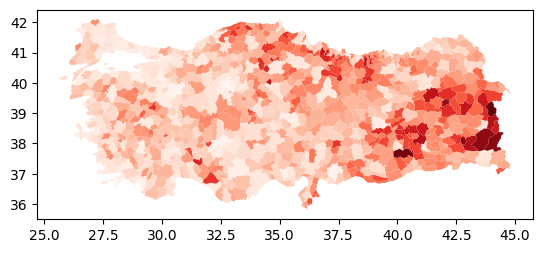

In [41]:
df.plot(column="Okuma yazma bilen fakat bir okul bitirmeyen",cmap="Reds")

<Axes: >

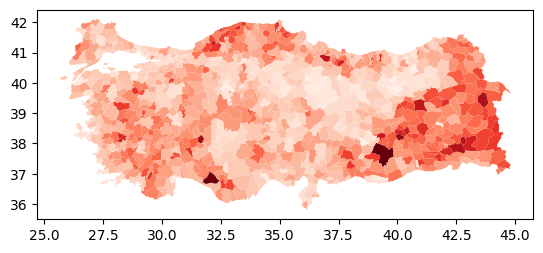

In [42]:
df.plot(column="invalid vote",cmap="Reds")

In [43]:
df["invalid_vote_ratio"]= df["Okuma yazma bilen fakat bir okul bitirmeyen"]/df["invalid vote"]

<Axes: >

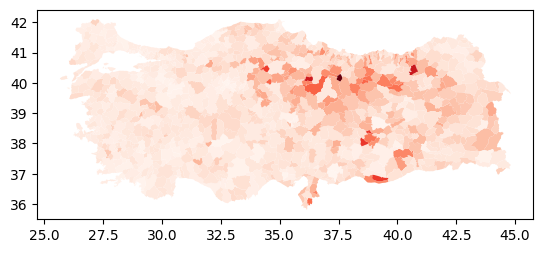

In [44]:
df.plot(column="invalid_vote_ratio",cmap="Reds")

### Apply Isolation Forest

In [45]:
X= df.loc[:,["invalid vote","Okuma yazma bilen fakat bir okul bitirmeyen"]]
X

,,invalid vote,Okuma yazma bilen fakat bir okul bitirmeyen
province,district,,
Kilis,Elbeyli,0.020023,0.047264
Çorum,Dodurga,0.047619,0.078231
Eskişehir,Mahmudiye,0.042998,0.046994
Konya,Tuzlukçu,0.039643,0.080889
Aksaray,Sarıyahşi,0.046694,0.107957
...,...,...,...
Kastamonu,İnebolu,0.039965,0.064233
İstanbul,Şile,0.023791,0.023287
Adana,Seyhan,0.026598,0.012570


<Axes: >

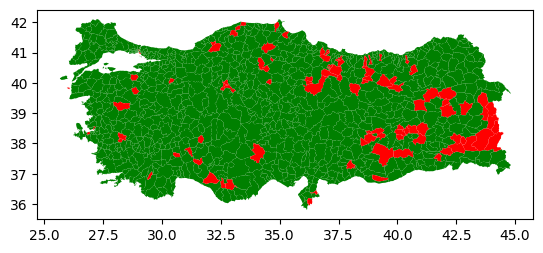

In [46]:
from sklearn.ensemble import IsolationForest
from matplotlib.colors import ListedColormap

iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X)
# Anomalies are indicated with -1
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] != -1]

cmap = ListedColormap(['red', 'green'])  # Red for -1, Green for 1

df.plot(column="anomaly",cmap=cmap)

In [47]:
X= X.copy()
X=X.reset_index()
X.set_index("district")
X.head()

,province,district,invalid vote,Okuma yazma bilen fakat bir okul bitirmeyen
0,Kilis,Elbeyli,0.020023,0.047264
1,Çorum,Dodurga,0.047619,0.078231
2,Eskişehir,Mahmudiye,0.042998,0.046994
3,Konya,Tuzlukçu,0.039643,0.080889
4,Aksaray,Sarıyahşi,0.046694,0.107957


<Axes: >

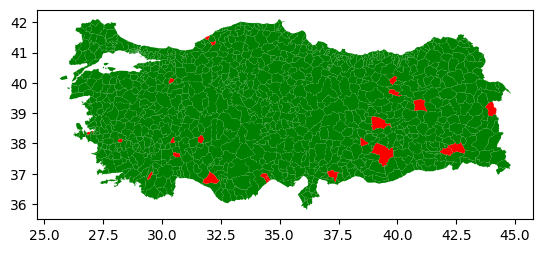

In [57]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
clf = LocalOutlierFactor(n_neighbors=10)
df["anomaly"]=clf.fit_predict(X.loc[:,["Okuma yazma bilen fakat bir okul bitirmeyen","invalid vote"]])
df.plot(column="anomaly",cmap=cmap)

In [119]:
from sklearn.preprocessing import MinMaxScaler
X_scaled= X.copy()
scaler = MinMaxScaler()
X_scaled.loc[:,["invalid vote","Okuma yazma bilen fakat bir okul bitirmeyen"]] = scaler.fit_transform(X.loc[:,["invalid vote","Okuma yazma bilen fakat bir okul bitirmeyen"]]  )

In [58]:
import matplotlib.pyplot as plt
os.environ["OMP_NUM_THREADS"] = '4'
from sklearn.cluster import KMeans
n_clusters=7
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X.loc[:,["Okuma yazma bilen fakat bir okul bitirmeyen","invalid vote"]])
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

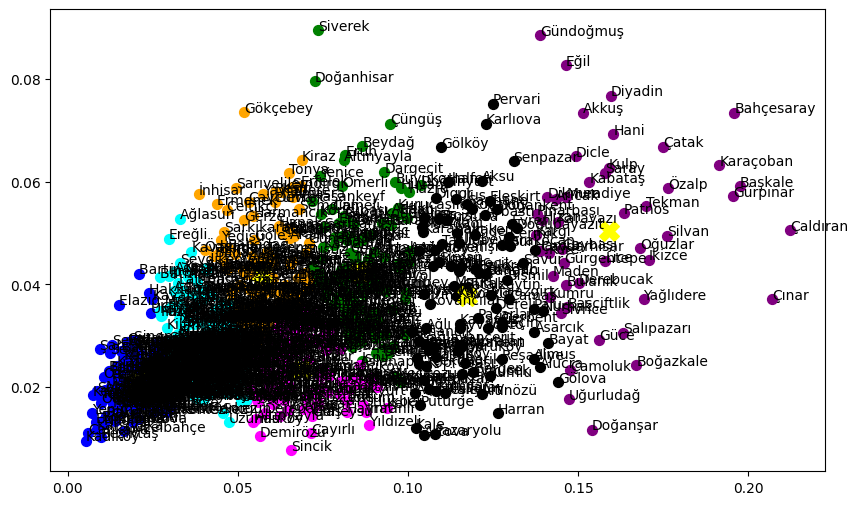

In [59]:
selected_column= "Okuma yazma bilen fakat bir okul bitirmeyen"
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["blue","green","orange","purple","black","magenta","cyan","black","purple","yellow"]
for i in range(n_clusters):
    res = X[labels == i]  
    for idx in res.index:
        ax.scatter(res.loc[idx,selected_column], res.loc[idx,"invalid vote"], s=50,color=colors[i]  , label=f'Cluster {i+1}')
       # if (X.loc[idx,"new_col"]/ X.loc[idx,"invalid vote"])<2:
        ax.annotate(res.loc[idx,"district"], (res.loc[idx,selected_column],  res.loc[idx,"invalid vote"]))
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, color='yellow', marker='X', label='Centroids')
  

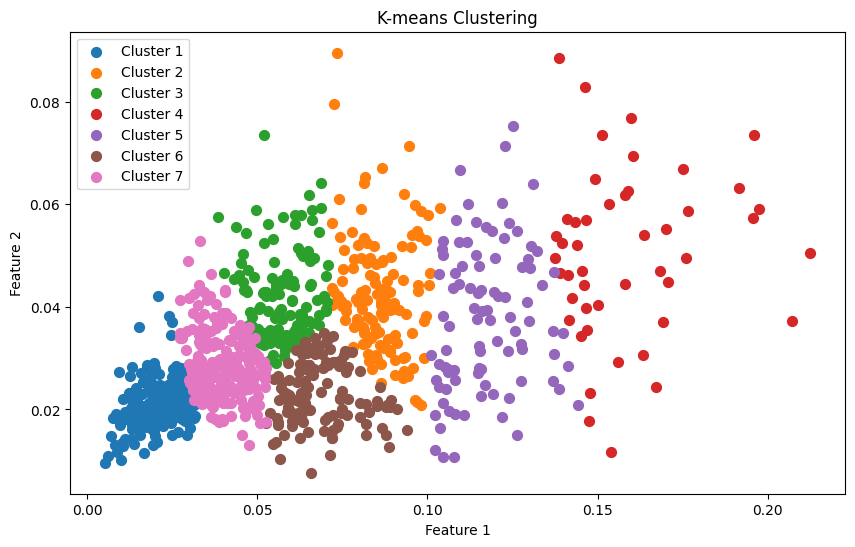

In [60]:
colors = ["blue","green","orange","purple","black","magenta","cyan","purple","yellow","aquamarine","mediumseagreen","gray","tomato","gold","pink","chartreuse","peru","darkviolet",
         "darkkhaki","teal","lightgray","skyblue","lightsalmon"]
plt.figure(figsize=(10, 6))
for i in range(n_clusters):
    res = X[labels == i]  
    plt.scatter(res.loc[:, selected_column],res.loc[:, "invalid vote"], s=50, label=f'Cluster {i+1}')
    

#plt.scatter(centroids[:, 0], centroids[:, 1], s=200, color='yellow', marker='X', label='Centroids')
plt.title('K-means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [61]:
len(colors)

23

In [62]:
from sklearn.cluster import DBSCAN
import numpy as np
clustering = DBSCAN(eps=.01, min_samples=1,leaf_size=256).fit(X.loc[:,[selected_column,"invalid vote"]])
labels=clustering.labels_
X["labels"]=labels
set(labels)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}

In [63]:
n_clusters=len(set(labels))
unique_labels_list = list(set(labels))

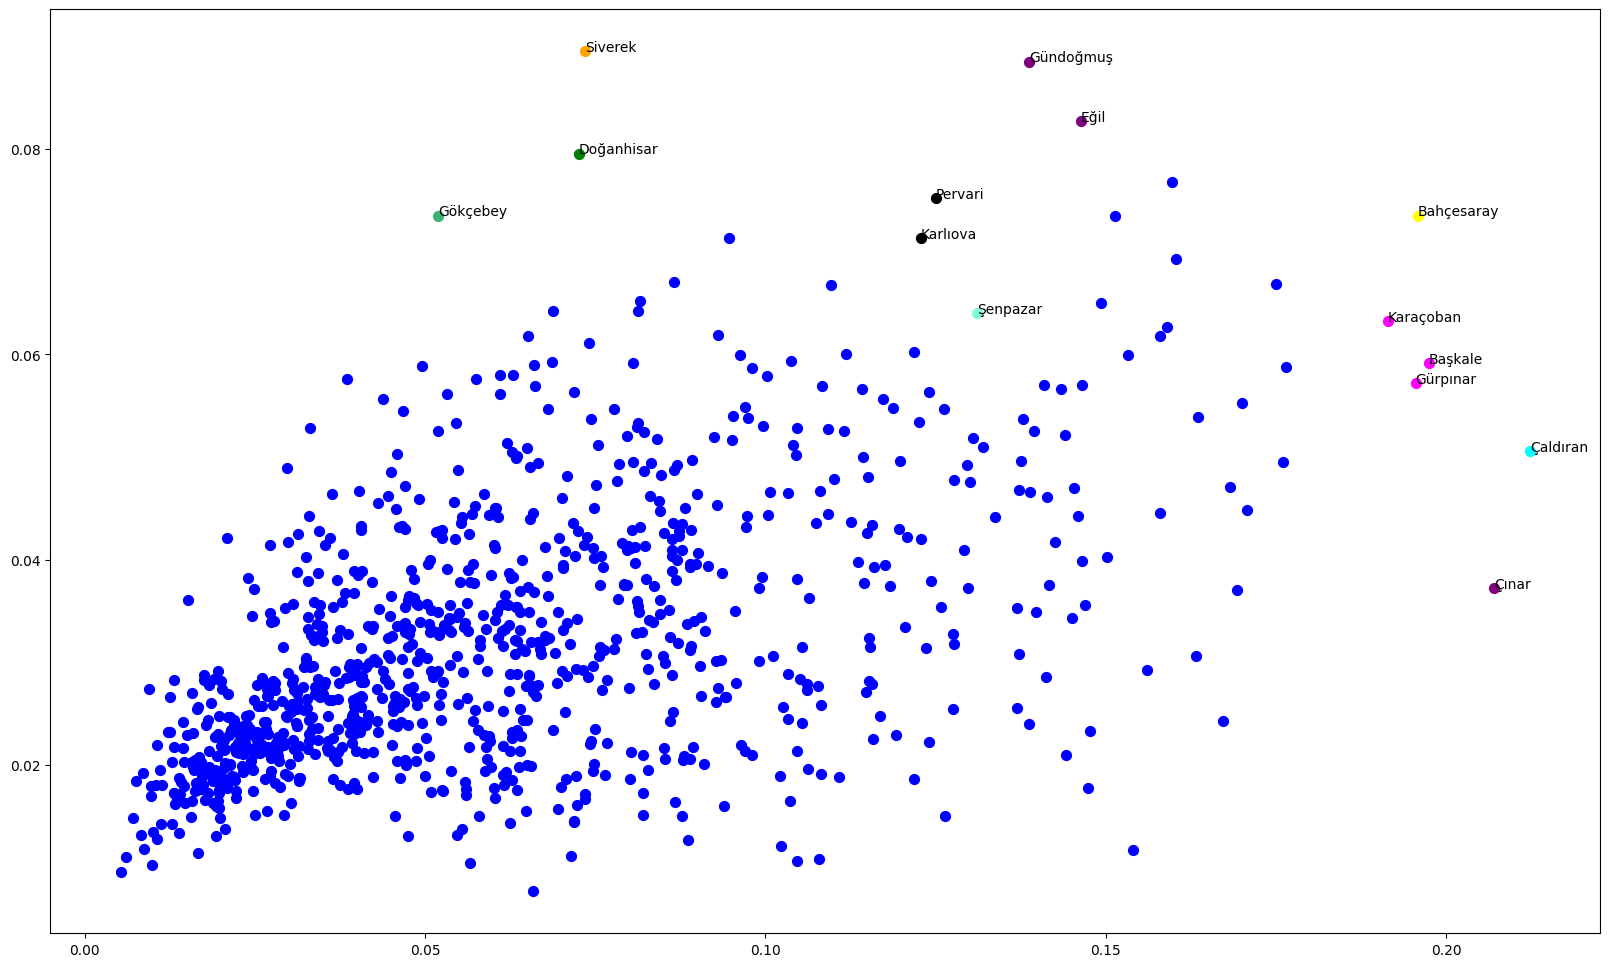

In [64]:
fig, ax = plt.subplots(figsize=(20, 12))
for i,label in enumerate(unique_labels_list):
    res = X[labels == label]  
    for idx in res.index:
        ax.scatter(res.loc[idx,selected_column], res.loc[idx,"invalid vote"], s=50,color=colors[i]  , label=f'Cluster {i+1}')
       # if (X.loc[idx,"new_col"]/ X.loc[idx,"invalid vote"])<2:
        if i>0:
            ax.annotate(res.loc[idx,"district"], (res.loc[idx,selected_column],  res.loc[idx,"invalid vote"]))
#plt.scatter(centroids[:, 0], centroids[:, 1], s=200, color='yellow', marker='X', label='Centroids')
  

In [71]:
# Fit linear regression model
from sklearn.linear_model import LinearRegression

data=X
model = LinearRegression()
model.fit(data[['Okuma yazma bilen fakat bir okul bitirmeyen']], data['invalid vote'])

# Predict y values
data['y_pred'] = model.predict(data[['Okuma yazma bilen fakat bir okul bitirmeyen']])
# Calculate residuals
data['residuals'] = data['invalid vote'] - data['y_pred']
# Define a threshold for outliers (e.g., 2 standard deviations from the mean)
threshold = 2 * data['residuals'].std()

# Identify outliers
data["outliers"] = np.abs(data['residuals'] )> threshold
data['up_outliers'] = data['residuals'] > threshold
data['down_outliers'] = data['residuals'] < -threshold
# Separate outliers and inliers
down_outliers = data[data['down_outliers']]
up_outliers = data[data['up_outliers']]
inliers = data[~data['outliers']]

# Print outliers
print("Outliers detected:")
print(sum(data["outliers"]))

Outliers detected:
53


In [72]:
data

,province,district,invalid vote,Okuma yazma bilen fakat bir okul bitirmeyen,labels,y_pred,residuals,up_outlier,down_outlier,up_outliers,down_outliers,outliers
0,Kilis,Elbeyli,0.020023,0.047264,0,0.029301,-0.009278,False,False,False,False,False
1,Çorum,Dodurga,0.047619,0.078231,0,0.034964,0.012655,False,False,False,False,False
2,Eskişehir,Mahmudiye,0.042998,0.046994,0,0.029252,0.013747,False,False,False,False,False
3,Konya,Tuzlukçu,0.039643,0.080889,0,0.035450,0.004193,False,False,False,False,False
4,Aksaray,Sarıyahşi,0.046694,0.107957,0,0.040399,0.006295,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
968,Kastamonu,İnebolu,0.039965,0.064233,0,0.032404,0.007561,False,False,False,False,False
969,İstanbul,Şile,0.023791,0.023287,0,0.024917,-0.001126,False,False,False,False,False
970,Adana,Seyhan,0.026598,0.012570,0,0.022958,0.003641,False,False,False,False,False
971,Afyonkarahisar,Çobanlar,0.025713,0.045363,0,0.028954,-0.003241,False,False,False,False,False


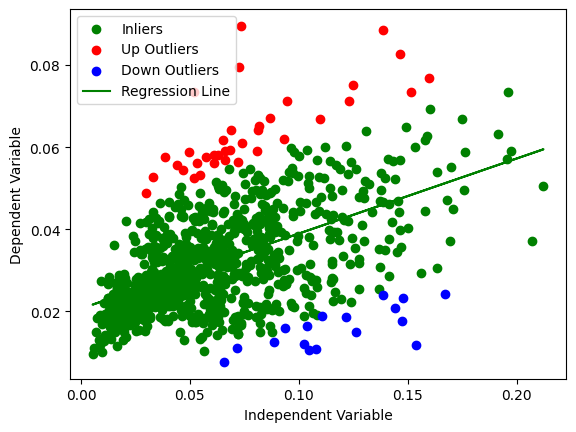

In [74]:
# Plot the data and regression line
plt.scatter(inliers[selected_column], inliers['invalid vote'], label='Inliers', color='green')
plt.scatter(up_outliers[selected_column], up_outliers['invalid vote'], label='Up Outliers', color='red')
plt.scatter(down_outliers[selected_column], down_outliers['invalid vote'], label='Down Outliers', color='blue')

plt.plot(data[selected_column], data['y_pred'], label='Regression Line', color='green')
plt.xlabel('Independent Variable')
plt.ylabel('Dependent Variable')
plt.legend()
plt.show()

# ANALYSIS

In [75]:
df_edu.head(5)

Okuma yazma bilmeyen  \
province district                          
Adana    Aladağ                      684   
         Ceyhan                     2159   
         Feke                        502   
         Karaisalı                  1202   
         Karataş                     683   

                    Okuma yazma bilen fakat bir okul bitirmeyen  İlkokul  \
province district                                                          
Adana    Aladağ                                             693     2411   
         Ceyhan                                            4688     4892   
         Feke                                               994     3673   
         Karaisalı                                          763     5266   
         Karataş                                            744     4652   

                    İlköğretim  Ortaokul veya dengi okul  \
province district                                          
Adana    Aladağ           1813                      1965   
         Ceyhan           8339                     11053   
         Feke             1552                      1932   
         Karaisalı        1770                      2346   
         Karataş          1484                      2833   

                    Lise veya dengi okul  Yüksekokul veya fakülte  \
province district                                                   
Adana    Aladağ                     3297                     1324   
         Ceyhan                     2732                     5985   
         Feke                       2761                     1184   
         Karaisalı                  3849                     1914   
         Karataş                    4415                     1836   

                    Yüksek lisans  Doktora  Bilinmeyen  Toplam  
province district                                               
Adana    Aladağ               105        9          29   12330  
         Ceyhan              1345       72         750     103  
         Feke                  82       14          94   12788  
         Karaisalı            149        7          46   14908  
         Karataş              166       10         209   14727

In [77]:
df_edu = df_edu.groupby(["province","district"]).sum()

In [78]:
df_edu.head()

Okuma yazma bilmeyen  \
province district                          
Adana    Aladağ                      684   
         Ceyhan                     2159   
         Feke                        502   
         Karaisalı                  1202   
         Karataş                     683   

                    Okuma yazma bilen fakat bir okul bitirmeyen  İlkokul  \
province district                                                          
Adana    Aladağ                                             693     2411   
         Ceyhan                                            4688     4892   
         Feke                                               994     3673   
         Karaisalı                                          763     5266   
         Karataş                                            744     4652   

                    İlköğretim  Ortaokul veya dengi okul  \
province district                                          
Adana    Aladağ           1813                      1965   
         Ceyhan           8339                     11053   
         Feke             1552                      1932   
         Karaisalı        1770                      2346   
         Karataş          1484                      2833   

                    Lise veya dengi okul  Yüksekokul veya fakülte  \
province district                                                   
Adana    Aladağ                     3297                     1324   
         Ceyhan                     2732                     5985   
         Feke                       2761                     1184   
         Karaisalı                  3849                     1914   
         Karataş                    4415                     1836   

                    Yüksek lisans  Doktora  Bilinmeyen  Toplam  
province district                                               
Adana    Aladağ               105        9          29   12330  
         Ceyhan              1345       72         750     103  
         Feke                  82       14          94   12788  
         Karaisalı            149        7          46   14908  
         Karataş              166       10         209   14727

In [80]:
df_edu["0.seviye"] = df_edu[df_edu.columns[:5]].sum(axis=1) # ortaokul öncesi
df_edu["1.seviye"] = df_edu[df_edu.columns[[5]]].sum(axis=1) # ortaokul
df_edu["2.seviye"]= df_edu[df_edu.columns[6:9]].sum(axis=1) # lise ve üstü
df_edu.drop(columns=df_edu.columns[:9],inplace=True)
df_edu.head()

IndexError: index 5 is out of bounds for axis 0 with size 5

In [81]:
df_election.head()

Oy kullanan seçmen sayısı  Geçerli oy sayısı  invalid vote
province district                                                             
Adana    Seyhan                        489246             476233         13013
         Ceyhan                         98825              95960          2865
         Feke                           11039              10590           449
         Karaisalı                      16011              15573           438
         Karataş                        15307              14995           312

In [82]:
# Symettric difference of two sets of indices must be empty for consistency
set(df_election.index.unique()).symmetric_difference(set(df_edu.index.unique()))

set()

In [83]:
df = pd.merge(df_edu, df_election, left_index=True, right_index=True)
df.head()

Bilinmeyen  Toplam  0.seviye  1.seviye  2.seviye  \
province district                                                      
Adana    Aladağ             29   12330     24660      3297      1438   
         Ceyhan            750     103     42118      2732      7402   
         Feke               94   12788     25576      2761      1280   
         Karaisalı          46   14908     32220      3849      2070   
         Karataş           209   14727     31759      4415      2012   

                    Oy kullanan seçmen sayısı  Geçerli oy sayısı  invalid vote  
province district                                                               
Adana    Aladağ                         11220              10810           410  
         Ceyhan                         98825              95960          2865  
         Feke                           11039              10590           449  
         Karaisalı                      16011              15573           438  
         Karataş                        15307              14995           312

In [84]:
df.corr()["Okuma yazma bilmeyen"].sort_values(ascending=False)

KeyError: 'Okuma yazma bilmeyen'

In [ ]:
df.corr()["Yüksek lisans"].sort_values(ascending=False)

In [85]:
df.corr()["1.seviye"].sort_values(ascending=False)

1.seviye                     1.000000
0.seviye                     0.718801
2.seviye                     0.536994
invalid vote                 0.046665
Oy kullanan seçmen sayısı   -0.011829
Geçerli oy sayısı           -0.013149
Bilinmeyen                  -0.020911
Toplam                      -0.191925
Name: 1.seviye, dtype: float64

In [ ]:
df.corr()["2.seviye"].sort_values(ascending=False)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
from sklearn.preprocessing import StandardScaler

ss = MinMaxScaler()
df_edu_scaled = pd.DataFrame(ss.fit_transform(df_edu),columns = df_edu.columns)
df_edu_scaled.head()

In [ ]:
def fun(x):
    return x/sum(x)
df_election_scaled = df_election.apply(fun, axis=1)#.sum(axis=1)  uncomment to check that sums up to 1 
df_edu_scaled = df_edu.apply(fun, axis=1)#.sum(axis=1)  uncomment to check that sums up to 1 

In [ ]:
df_scaled = pd.merge(df_edu_scaled, df_election_scaled, left_index=True, right_index=True)
df_scaled.head()

In [ ]:
df.corr()["0.seviye"].sort_values(ascending=False),df_scaled.corr()["0.seviye"].sort_values(ascending=False)

In [ ]:
df.corr()["1.seviye"].sort_values(ascending=False),df_scaled.corr()["1.seviye"].sort_values(ascending=False)